# Configuration

In [1]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score

sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2



In [ ]:
from pdata.data_read import read_unibind_file

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/process/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/benchmark/"

os.makedirs(output_path, exist_ok=True )

###########################################################
# Unibind data processing

unibind_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/unibind/UniBind_search_qlr7ymfp.tar.gz"

unibind_df, count_region_df = read_unibind_file(unibind_file)

unibind_df["CellLine"] = unibind_df["CellLine"].str.split('_').str[0]
count_region_df["CellLine"] = count_region_df["CellLine"].str.split('_').str[0]

print(unibind_df.head())
print(count_region_df.head())

unibind_df.to_pickle(output_path + "unibind_df.pkl")
count_region_df.to_pickle(output_path + "count_region_df.pkl")




# Other TF-recovery

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Top 40 AUC (Raw): 456.50
Top 40 AUC (Normalized): 0.5710


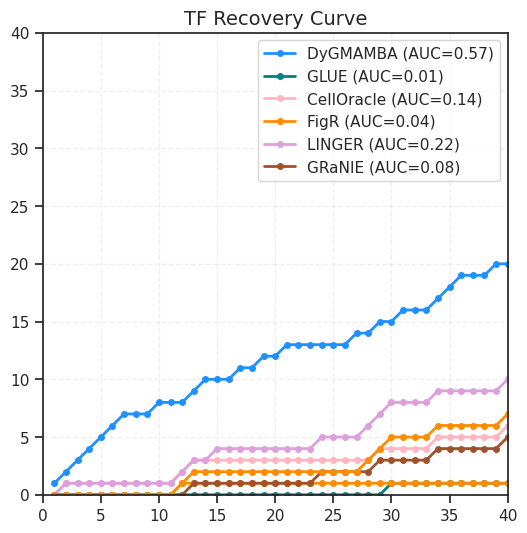

In [87]:
import sys
import os
import pickle
import pandas as pd
import anndata as ad
import numpy as np
import networkx as nx
from tqdm import tqdm
import scipy.sparse
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt



# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2

sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

from analysis.assess_tf_recovery import calculate_recovery_metrics
from pdata.benchmark_data import glue_read_ctx_grn

##############################################################################
#
#
##############################################################################



data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/benchmark/"

os.makedirs(output_path, exist_ok=True )

###########################################################
# Unibind data processing
 
benchmark_df = pd.read_pickle(output_path + "count_region_df.pkl")

ground_truth_ranked = benchmark_df.sort_values(by="PeakCount", ascending=False)["TF"].tolist()



##########################################################################
# DygMamba TF recovery
tf_peak_grn = ad.read_h5ad(data_path + "process/tf_peak_network.h5ad")

dyg_tfs = set(tf_peak_grn.var_names)

dyg_x, dyg_y, dyg_raw_auc, dyg_norm_auc = calculate_recovery_metrics(ground_truth_ranked, dyg_tfs, top_n=40)

print(f"Top 40 AUC (Raw): {dyg_raw_auc:.2f}")
print(f"Top 40 AUC (Normalized): {dyg_norm_auc:.4f}")

plt.figure(figsize=(6, 6))

# 绘制我们的方法的曲线
plt.plot(dyg_x, dyg_y, label=f'{"DyGMAMBA"} (AUC={dyg_norm_auc:.2f})', color='dodgerblue', linewidth=2, marker='o', markersize=4)

##########################################################################
# GLUE TF recovery

glue_grn = glue_read_ctx_grn(data_path + "data_glue/pruned_grn.csv")


df_edges = nx.to_pandas_edgelist(glue_grn, source="TF", target="Gene")

glue_tfs = set(df_edges["TF"])

glue_x, glue_y, glue_raw_auc, glue_norm_auc = calculate_recovery_metrics(ground_truth_ranked, glue_tfs, top_n=40)

plt.plot(glue_x, glue_y, label=f'{"GLUE"} (AUC={glue_norm_auc:.2f})', color='teal', linewidth=2, marker='o', markersize=4)

##########################################################################
# CellOracle TF recovery

celloracle_grn = pd.read_csv(data_path + "data_celloracle/celloracle_results/grn_df_" + "cluster0" + ".csv")

celloracle_grn.rename(columns={"source": "TF", "target": "Gene"}, inplace= True)

oracle_tf_gene = celloracle_grn[["TF", "Gene", "-logp"]].copy()

oracle_tfs = set(oracle_tf_gene["TF"])

oracle_x, oracle_y, oracle_raw_auc, oracle_norm_auc = calculate_recovery_metrics(ground_truth_ranked, oracle_tfs, top_n=40)

plt.plot(oracle_x, oracle_y, label=f'{"CellOracle"} (AUC={oracle_norm_auc:.2f})', color='lightpink', linewidth=2, marker='o', markersize=4)


##########################################################################
# FigR TF recovery

figr_grn = pd.read_csv(data_path + "data_FigR/TF_Gene_Network.csv")

figr_tfs = set(figr_grn["TF"])

figr_x, figr_y, figr_raw_auc, figr_norm_auc = calculate_recovery_metrics(ground_truth_ranked, figr_tfs, top_n=40)

plt.plot(figr_x, figr_y, label=f'{"FigR"} (AUC={figr_norm_auc:.2f})', 
         color='darkorange', linewidth=2, marker='o', markersize=4)

##########################################################################
# Linger TF recovery

linger_grn = pd.read_csv(data_path + "data_linger/train/cell_population_TF_RE_binding.txt", sep='\t')

linger_tfs = set(linger_grn.columns[1:])

linger_x, linger_y, linger_raw_auc, linger_norm_auc = calculate_recovery_metrics(ground_truth_ranked, linger_tfs, top_n=40)

plt.plot(linger_x, linger_y, label=f'{"LINGER"} (AUC={linger_norm_auc:.2f})', 
         color='plum', linewidth=2, marker='o', markersize=4)

##########################################################################
# GRaNIE TF recovery

granie_grn = pd.read_csv(data_path + "GRaNIE_output/GRaNIE_tf_gene_Links.csv")

granie_tfs = set(granie_grn["TF.name"])

granie_x, granie_y, granie_raw_auc, granie_norm_auc = calculate_recovery_metrics(ground_truth_ranked, granie_tfs, top_n=40)

plt.plot(granie_x, granie_y, label=f'{"GRaNIE"} (AUC={granie_norm_auc:.2f})', 
         color='sienna', linewidth=2, marker='o', markersize=4)

############################################################################
plt.title('TF Recovery Curve', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(0, 40)
plt.ylim(0, 40) # 或者是实际恢复的最大值

plt.savefig(output_path + 'TF_Recovery_Curve.png', dpi=300, bbox_inches='tight')

##########################################################################
# Pando TF recovery

pando_grn = pd.read_csv(data_path + "data_pando/tf_gene_network.csv")

pando_tfs = set(pando_grn["TF"])

pando_x, pando_y, pando_raw_auc, pando_norm_auc = calculate_recovery_metrics(ground_truth_ranked, pando_tfs, top_n=40)

plt.plot(pando_x, pando_y, label=f'{"FigR"} (AUC={pando_norm_auc:.2f})', 
         color='darkorange', linewidth=2, marker='o', markersize=4)


## Tau

In [101]:
import anndata as ad

cell_cluster = ['GM12878', 'HepG2', 'K562']

adata_dict = {}

for cell_type in cell_cluster:
        
    data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/process"

    adata_dict[cell_type] = ad.read_h5ad(data_path + "/rna_origin.h5ad")


In [102]:
import numpy as np
import pandas as pd
import scipy.sparse
from functools import reduce

def calculate_tau_from_dict(adata_dict):
    """
    计算字典中多个 AnnData 对象之间的基因 Tau 值 (特异性指数)。
    使用通用公式：Tau = sum(1 - (x / max(x))) / (N - 1)
    
    参数:
    ----------
    adata_dict : dict
        键为细胞类型名称 (str)，值为 AnnData 对象。
        假设每个 adata.X 已经是经过标准化和 Log 转换的数据 (log1p)。
        
    返回:
    ----------
    pd.DataFrame
        包含 'Tau' 值和各细胞类型原始平均表达量的表格。
    """
    
    # 获取所有的 AnnData 对象
    adatas = list(adata_dict.values())
    keys = list(adata_dict.keys())
    n_groups = len(keys)
    
    if n_groups < 2:
        raise ValueError("计算 Tau 值至少需要 2 个或以上的细胞类型数据。")

    print(f"正在处理 {n_groups} 个细胞类型: {keys}")

    # 1. 找到所有数据集共有的基因 (Intersection)
    # 使用 reduce 函数对所有 var_names 取交集
    common_genes = reduce(np.intersect1d, [ad.var_names for ad in adatas])
    print(f"共有基因数量: {len(common_genes)}")
    
    if len(common_genes) == 0:
        return pd.DataFrame()

    # 2. 提取数据并计算平均表达量 (Pseudo-bulk aggregation)
    express_data = {}
    
    for name, adata in adata_dict.items():
        # 提取共有基因的子集
        X_subset = adata[:, common_genes].X
        
        # 计算均值 (处理稀疏矩阵)
        if scipy.sparse.issparse(X_subset):
            # mean 返回的是 matrix 类型，需要转为 array 并展平
            mean_expr = np.array(X_subset.mean(axis=0)).flatten()
        else:
            mean_expr = np.mean(X_subset, axis=0)
            
        express_data[name] = mean_expr
    
    # 构建 DataFrame (行=基因, 列=细胞类型)
    df = pd.DataFrame(express_data, index=common_genes)
    
    # 3. 计算通用 Tau 值
    # ---------------------------------------------------------
    # 公式: sum(1 - (expression / max_expression)) / (N - 1)
    # ---------------------------------------------------------
    
    # A. 获取每行的最大值 (Max expression across tissues)
    # 添加 epsilon 防止除以 0
    max_vals = df.max(axis=1)
    
    # B. 计算归一化表达量 (x_hat = x / max)
    #利用 pandas 的广播机制，每一列都除以 max_vals
    x_hat = df.div(max_vals + 1e-6, axis=0)
    
    # C. 计算求和部分: sum(1 - x_hat)
    sum_term = (1 - x_hat).sum(axis=1)
    
    # D. 最终 Tau 计算
    tau_values = sum_term / (n_groups - 1)
    
    # E. 处理全 0 的情况 (如果最大值是 0，说明所有组织都不表达，Tau 设为 NaN)
    tau_values[max_vals == 0] = np.nan
    
    # 将 Tau 结果加入 DataFrame
    df['Tau'] = tau_values
    
    # 按 Tau 值降序排列
    return df.sort_values('Tau', ascending=False)

In [ ]:
tau_df = calculate_tau_from_dict(adata_dict)

In [ ]:
print(tau_df[['Tau']].head(10)) # 只看 Tau 列

# 如果想看特定基因在各细胞系的表达情况
print(tau_df.head(5))

# 获取 Tau > 0.8 的高特异性基因
high_spec_genes = tau_df[tau_df['Tau'] > 0.8].index.tolist()
print(f"高特异性基因数量: {len(high_spec_genes)}")

In [93]:
glue_grn = glue_read_ctx_grn(data_path + "data_glue/pruned_grn.csv")
glue_df = nx.to_pandas_edgelist(glue_grn, source="TF", target="Gene")
glue_df

,TF,Gene
0,JUNB,XPNPEP3
1,JUNB,UBQLN1
2,JUNB,THADA
3,JUNB,GLOD4
4,JUNB,YWHAH
5,JUNB,DDX28
6,THAP11,SNX1
7,THAP11,PEX14
8,THAP11,FBXO46
9,THAP11,PHF13


In [94]:
active_grn

,TF,Target
0,ARGFX,ABCC4
1,ARGFX,BAG5
2,ARGFX,BLCAP
3,ARGFX,CDC42EP4
4,ARGFX,CMTM6
...,...,...
231226,Zic3,ZNF76
231227,Zic3,ZNF765
231228,Zic3,ZNF768
231229,Zic3,ZNF865


# Other TF-Gene

## TF-Gene Network

In [183]:
from pdata.data_preprocess import filter_jaspar_tf, adata_to_dataframe

cell_type = "HepG2"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/process/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/"

unibind_df_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/benchmark/unibind_df.pkl"

model_result_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/data_dyg/"

os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(model_result_path + "atac.h5ad")
adata_rna = ad.read_h5ad(model_result_path + "rna.h5ad")
total_peak = set(adata_atac.var_names)

##################################################################
########################################################################################

jaspar_tf_region_file = data_path + "jaspar_data_processed.h5ad"
jaspar_data = ad.read_h5ad(jaspar_tf_region_file)
adata_region_tf = filter_jaspar_tf(jaspar_data)


coo_matrix = adata_region_tf.X.tocoo()
tf_peak_df = pd.DataFrame({
    'Peak': adata_region_tf.obs_names[coo_matrix.row],
    'TF': adata_region_tf.var_names[coo_matrix.col],
    'value': coo_matrix.data
})
tf_peak_df = tf_peak_df[tf_peak_df['TF'].isin(set(adata_rna.var_names))]
tf_peak_df = tf_peak_df[tf_peak_df["Peak"].isin(set(adata_atac.var_names))]

print("*"*50)
print(adata_region_tf)
print(f"TF-Peak: {tf_peak_df['TF'].nunique()}, {tf_peak_df['Peak'].nunique()}, edge: {len(tf_peak_df)}")
print("*"*50)

dygmamba_tf_peak_df = tf_peak_df
dygmamba_tf_peak_df = dygmamba_tf_peak_df.rename(columns={"value":"predict"})

total_peak = set(adata_atac.var_names)
dygmamba_tf_peak_df = dygmamba_tf_peak_df[dygmamba_tf_peak_df["Peak"].isin(total_peak)].copy()

########################################################################################

feat_path = model_result_path + "edge_features.npy"
edge_label_path = model_result_path + "edge_labels.npy"

Edge_feature = np.load(feat_path, mmap_mode="r")
Edge_feature = Edge_feature.reshape(-1,1).copy()
Edge_label = np.load(edge_label_path, mmap_mode="r")
Edge_label = Edge_label.reshape(-1,1).copy()

with open(model_result_path + "node_feature_data.pkl", "rb") as f:
    load_data = pickle.load(f)

Node_feature = load_data['node_feature']

Node_id = pd.read_pickle(model_result_path + "node_id.pkl")

graph_df = pd.read_pickle(model_result_path + "Graph_df.pkl")
graph_df["Unnamed"] = graph_df.index
name_list = ["Unnamed", "source_node", "target_node", "time", "label", "edge_idx"]
New_Graph = graph_df[name_list].copy()
New_Graph.columns = ['Unnamed: 0', 'u', 'i', 'ts', 'label', 'idx']


####################################################################################

####################################################################################
result_path = model_result_path + 'my_result_run0.npy'
predict_edge_label = np.load(result_path)

New_Graph["predict"] = predict_edge_label
predict_grn = New_Graph.copy()

mapping_series = Node_id["name"]
predict_grn['source'] = (predict_grn['u'] - 1).map(mapping_series)
predict_grn['target'] = (predict_grn['i'] - 1).map(mapping_series)

peak_gene_df = predict_grn[['source', 'target', 'ts','predict']].rename(
    columns={'source': 'Peak', 'target': 'Gene'}
)
peak_gene_df = peak_gene_df[~peak_gene_df["Gene"].str.startswith('chr')].copy()

print("*"*50)
print(f"Peak-Gene: {peak_gene_df['Peak'].nunique()}, {peak_gene_df['Gene'].nunique()}, edge:{len(peak_gene_df)}")
print("*"*50)

#################################################################################### 
dygmamba_tf_peak_df = dygmamba_tf_peak_df.rename(columns={"predict":"value"})
peak_gene_grn = peak_gene_df[peak_gene_df["Peak"].isin(total_peak)]
merged_df = pd.merge(dygmamba_tf_peak_df, peak_gene_grn, on='Peak')

tf_gene_grn = merged_df.groupby(['TF', 'Gene', 'ts']).agg(
    peak_num=('Peak', 'nunique'),   # 对 Peak 列做去重计数，新列名叫 peak_num
    avg_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()

# 查看结果
print("*"*50)
print(f"Dygmamba TF-Peak: {dygmamba_tf_peak_df['TF'].nunique()}, {dygmamba_tf_peak_df['Peak'].nunique()},\
    edge: {len(dygmamba_tf_peak_df)}")
print(f"Peak-Gene: {peak_gene_df['Peak'].nunique()}, {peak_gene_df['Gene'].nunique()}, edge:{len(peak_gene_df)}")
print(f"TF-Gene: {tf_gene_grn['TF'].nunique()}, {tf_gene_grn['Gene'].nunique()}, edge: {len(tf_gene_grn)}")

tf_gene_grn.to_pickle(model_result_path + "new_tf_gene_grn_1224.pkl")

avg_active_tf_gene_grn = tf_gene_grn.groupby(['TF', 'Gene']).agg(
    avg_ts_weight=('total_weight', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('total_weight', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()
avg_active_tf_gene_grn.to_pickle(model_result_path + "average_active_tf_gene_grn.pkl")

pivoted_grn = tf_gene_grn.pivot_table(
    index=['TF', 'Gene'],
    columns='ts',
    values='total_weight',
    fill_value=0
)
pivoted_grn['average_active_weight'] = pivoted_grn.mean(axis=1)
avg_global_tf_gene_grn = pivoted_grn.reset_index()
avg_global_tf_gene_grn = avg_global_tf_gene_grn[["TF","Gene","average_active_weight"]].copy()
avg_global_tf_gene_grn.columns.name = None
avg_global_tf_gene_grn.to_pickle(model_result_path + "average_global_tf_gene_grn.pkl")

print("*"*50)
print(f"TF-Gene: {tf_gene_grn['TF'].nunique()}, {tf_gene_grn['Gene'].nunique()}, edge: {len(tf_gene_grn)}")
print(f"avg active TF-Gene: {avg_active_tf_gene_grn['TF'].nunique()}, {avg_active_tf_gene_grn['Gene'].nunique()},\
    edge: {len(avg_active_tf_gene_grn)}")
print(f"avg global TF-Gene: {avg_global_tf_gene_grn['TF'].nunique()}, {avg_global_tf_gene_grn['Gene'].nunique()},\
    edge: {len(avg_global_tf_gene_grn)}")
print("*"*50)


步骤 1: 过滤 Peaks (行)
  > 找到 68947 / 68947 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 850 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (68947, 850)
**************************************************
AnnData object with n_obs × n_vars = 68947 × 850
TF-Peak: 17, 4995, edge: 29909
**************************************************
**************************************************
Peak-Gene: 30814, 1999, edge:1521690
**************************************************
**************************************************
Dygmamba TF-Peak: 17, 4995,    edge: 29909
Peak-Gene: 30814, 1999, edge:1521690
TF-Gene: 17, 1917, edge: 3652022
**************************************************
TF-Gene: 17, 1917, edge: 3652022
avg active TF-Gene: 17, 1917,    edge: 20259
avg global TF-Gene: 17, 1917,    edge: 20259
**************************************************


## Benchmark

In [80]:
from analysis.assess_tf_gene import evaluate_predictability, dyg_tf_gene_data

from analysis.assess_tf_gene import evaluate_predictability

from pdata.benchmark_data import glue_read_ctx_grn

import networkx as nx

import seaborn as sns



data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/"

output_path = data_path + "benchmark/"
os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(data_path + "process/atac_processed.h5ad")
adata_rna = ad.read_h5ad(data_path + "process/rna_processed.h5ad")
matrix_df = pd.DataFrame(adata_rna.X.toarray(), index=adata_rna.obs_names,
                            columns=adata_rna.var_names)

##########################################################################
# dyg TF-Gene predictability

dyg_result_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/data_dyg/"
avg_active_tf_gene_grn = pd.read_pickle(dyg_result_path + "average_active_tf_gene_grn.pkl")
avg_global_tf_gene_grn = pd.read_pickle(dyg_result_path + "average_global_tf_gene_grn.pkl")

active_grn = avg_active_tf_gene_grn[["TF","Gene"]].copy()
active_grn.rename(columns={'Gene':'Target'},inplace = True)

active_result, trained_models = evaluate_predictability(matrix_df, active_grn)


global_grn = avg_global_tf_gene_grn[["TF","Gene"]].copy()
global_grn.rename(columns={'Gene':'Target'},inplace = True)

global_result, global_trained_models = evaluate_predictability(matrix_df, global_grn)

##########################################################################
# GLUE TF-Gene predictability

glue_grn = glue_read_ctx_grn(data_path + "data_glue/pruned_grn.csv")
glue_df = nx.to_pandas_edgelist(glue_grn, source="TF", target="Gene")

glue_df.rename(columns={'Gene':'Target'},inplace = True)
glue_result, glue_trained_models = evaluate_predictability(matrix_df, glue_df)

##########################################################################
# FigR TF-Gene predictability

figr_grn = pd.read_csv(data_path + "data_FigR/TF_Gene_Network.csv")
figr_df = figr_grn[["TF","Target_Gene"]].copy()
figr_df.rename(columns={'Target_Gene':'Target'},inplace = True)

figr_result, figr_trained_models = evaluate_predictability(matrix_df, figr_df)

##########################################################################
# Celloracle TF-Gene predictability

celloracle_grn = pd.read_csv(data_path + "data_celloracle/celloracle_results/grn_df_" + "cluster0" + ".csv")

celloracle_grn.rename(columns={"source": "TF", "target": "Gene"}, inplace= True)

celloracle_df = celloracle_grn[["TF", "Gene"]].copy()
celloracle_df.rename(columns={'Gene':'Target'},inplace = True)


celloracle_result, celloracle_trained_models = evaluate_predictability(matrix_df, celloracle_df)


##########################################################################
# LINGER TF-Gene predictability

linger_grn = pd.read_csv(data_path + "data_linger/train/cell_population_trans_regulatory.txt", sep='\t')
linger_grn = linger_grn.rename(columns={'Unnamed: 0': 'Gene'})
linger_df= linger_grn.melt(id_vars=['Gene'], var_name='TF', value_name='regulation')

linger_df = linger_df[["TF", "Gene"]].copy()
linger_df.rename(columns={'Gene':'Target'},inplace = True)

linger_result, linger_trained_models = evaluate_predictability(matrix_df, linger_df)

##########################################################################
# GRaNIE TF-Gene predictability

granie_grn = pd.read_csv(data_path + "GRaNIE_output/GRaNIE_tf_gene_Links.csv")
granie_df = granie_grn[["TF.name", "gene.name"]].copy()
granie_df.rename(columns={"TF.name": "TF", "gene.name": "Target"}, inplace=True)
granie_result, granie_trained_models = evaluate_predictability(matrix_df, granie_df)

##########################################################################
# Pando TF-Gene predictability

pando_grn = pd.read_csv(data_path + "data_pando/tf_gene_network.csv")

pando_df = pando_grn[["TF", "Gene"]].copy()
pando_df.rename(columns={"Gene": "Target"}, inplace=True)
pando_result, pando_trained_models = evaluate_predictability(matrix_df, pando_df)


>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...


<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

In [161]:
active_grn

,TF,Gene
0,ARGFX,ABCC4
1,ARGFX,BAG5
2,ARGFX,BLCAP
3,ARGFX,CDC42EP4
4,ARGFX,CMTM6
...,...,...
231226,Zic3,ZNF76
231227,Zic3,ZNF765
231228,Zic3,ZNF768
231229,Zic3,ZNF865


In [162]:
benchmark_tf_gene_df

,TF,Gene,value,label
0,TCF7L2,AACS,2,0
1,NR3C1,AACS,2,0
2,RFX1,AACS,4,0
3,ATF3,AACS,3,0
4,GABPA,AACS,7,1
...,...,...,...,...
90818,FOXA2,ZYX,12,1
90819,ELF1,ZYX,8,1
90820,CTCF,ZYX,13,1
90821,BHLHE40,ZYX,10,1


In [163]:
print(f"dyg tf num.: {len(set(active_grn['TF']))}, benchmark tf num.: {len(set(benchmark_tf_gene_df['TF']))}, \
    overlap tf num.: {len(set(active_grn['TF']).intersection(set(benchmark_tf_gene_df['TF'])))}")

dyg tf num.: 850, benchmark tf num.: 48,     overlap tf num.: 41


In [181]:
tf_peak_df

,Peak,TF,value
0,chr10-100009264-100010410,Atf3,1
1,chr10-100009264-100010410,Atoh1,1
2,chr10-100009264-100010410,BACH1,1
3,chr10-100009264-100010410,BACH2,1
4,chr10-100009264-100010410,BATF,1
...,...,...,...
10014555,chrY-2934882-2936205,Zfp961,1
10014556,chrY-2934882-2936205,Zfx,1
10014557,chrY-2934882-2936205,Zic1::Zic2,1
10014558,chrY-2934882-2936205,Zic2,1


In [176]:
cell_type = "HepG2"
out_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/process/"
jaspar_data = pd.read_pickle(out_path + "jaspar_df.pkl")
jaspar_data.sort_values(by="p-value", ascending=True, inplace=True)
jaspar_tf_region_grn = jaspar_data[["TF_Symbol", "sequence_name", "score", "p-value"]].copy()
jaspar_tf_region_grn.rename(columns={"TF_Symbol": "TF", "sequence_name": "Region"}, inplace=True)
jaspar_tf_region_grn = jaspar_tf_region_grn[jaspar_tf_region_grn["TF"].isin(adata_rna.var_names)]


print(f"dyg tf num.: {len(set(jaspar_tf_region_grn['TF']))}, benchmark tf num.: {len(set(benchmark_tf_gene_df['TF']))}, \
    overlap tf num.: {len(set(jaspar_tf_region_grn['TF']).intersection(set(benchmark_tf_gene_df['TF'])))}")

dyg tf num.: 64, benchmark tf num.: 48,     overlap tf num.: 6


In [180]:
len(set(tf_peak_df["TF"]) & set(adata_rna.var_names))

64

## Total Correlation

/tmp/ipykernel_105301/2129968994.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/tmp/ipykernel_105301/2129968994.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


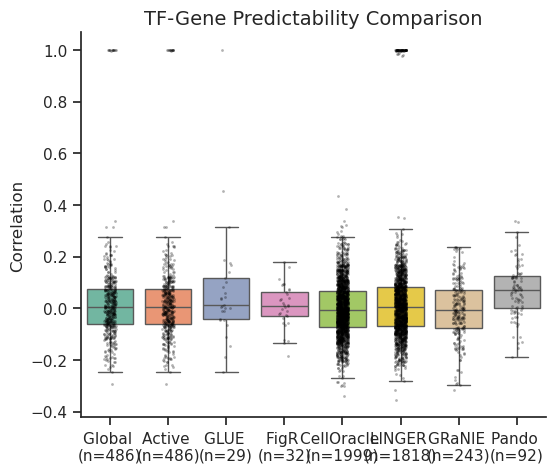

In [83]:
##########################################################################
#
#
##########################################################################

global_result["Method"] = "Global"
active_result["Method"] = "Active"
glue_result["Method"] = "GLUE"
figr_result["Method"] = "FigR"
celloracle_result["Method"] = "CellOracle"
linger_result["Method"] = "LINGER"
granie_result["Method"] = "GRaNIE"
pando_result["Method"] = "Pando"
df_combined = pd.concat([global_result[['Correlation', 'Method']], 
                        active_result[['Correlation', 'Method']],
                        glue_result[['Correlation', 'Method']],
                        figr_result[['Correlation', 'Method']],
                        celloracle_result[['Correlation', 'Method']],
                        linger_result[['Correlation', 'Method']],
                        granie_result[['Correlation', 'Method']],
                        pando_result[['Correlation', 'Method']]])

plt.figure(figsize=(6, 5))

# 定义顺序 (防止自动排序乱掉)
my_order = ['Global', 'Active','GLUE', 'FigR', 'CellOracle', 
            'LINGER', 'GRaNIE', "Pando"]

# 4. 绘制箱形图
# Seaborn 会自动识别 'Method' 列中的组别，并独立计算每个组的箱子
ax = sns.boxplot(data=df_combined, 
                x='Method', 
                y='Correlation', 
                order=my_order, 
                palette="Set2",
                showfliers=False) # 可选：不显示异常值点
sns.stripplot(data=df_combined, x='Method', y='Correlation', 
                order=my_order, color='black', size=2, alpha=0.3, jitter=True, ax=ax)
    
# =================================================
# 关键技巧：修改 X 轴标签，加上 (n=xxx)
# =================================================
# 计算每组的数量
n_A = len(global_result)
n_B = len(active_result)

# 创建新的标签列表
new_labels = [f"Global \n(n={n_A})", f"Active \n(n={n_B})",f"GLUE \n(n={len(glue_result)})",
              f"FigR \n(n={len(figr_result)})", f"CellOracle \n(n={len(celloracle_result)})",
              f"LINGER \n(n={len(linger_result)})", f"GRaNIE \n(n={len(granie_result)})",
              f"Pando \n(n={len(pando_result)})"]

# 应用新标签
ax.set_xticklabels(new_labels)

# 5. 美化
plt.title("TF-Gene Predictability Comparison", fontsize=14)
plt.ylabel("Correlation")
plt.xlabel("") # 清空 x 轴标题，因为标签里已经写了

sns.despine() # 去掉边框


## Top Correlation

/tmp/ipykernel_105301/2675751768.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/tmp/ipykernel_105301/2675751768.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


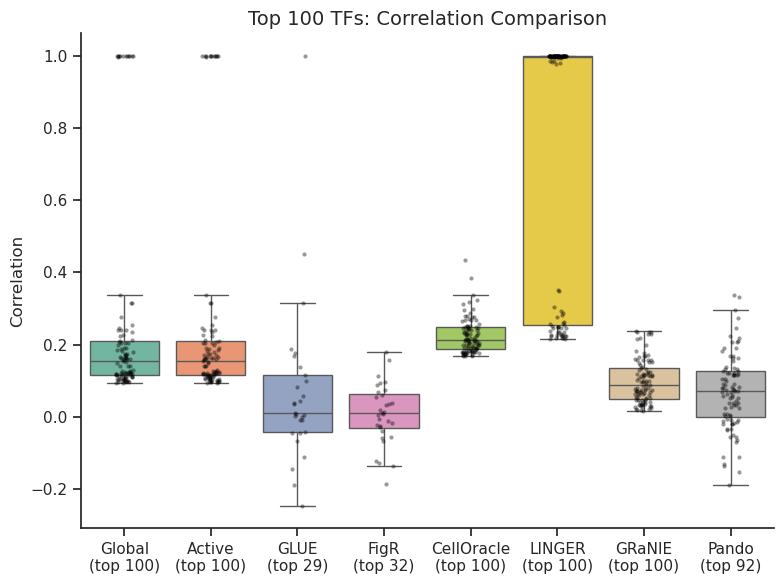

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_n_tf_comparison(result_dict, top_n=50, score_col='Correlation', my_order=None):
    """
    对比不同方法中表现最好的前 N 个 TF
    
    :param result_dict: 字典, key为方法名, value为对应的结果DataFrame
    :param top_n: 取前多少个TF
    :param score_col: 用于排序的列名，通常是 'Correlation' 或 'Precision'
    :param my_order: 指定绘图时的顺序
    """
    processed_list = []
    new_labels = []
    
    # 如果没指定顺序，默认按字典顺序
    if my_order is None:
        my_order = list(result_dict.keys())
        
    for method in my_order:
        if method not in result_dict:
            continue
            
        df = result_dict[method].copy()
        
        # 1. 核心操作：按得分降序排列，取前 N 个
        top_df = df.sort_values(by=score_col, ascending=False).head(top_n)
        top_df["Method"] = method
        processed_list.append(top_df[[score_col, 'Method']])
        
        # 2. 准备新的标签 (n=实际数量)
        actual_n = len(top_df)
        new_labels.append(f"{method}\n(top {actual_n})")
    
    # 合并数据
    df_combined = pd.concat(processed_list)
    
    # 3. 开始绘图
    plt.figure(figsize=(8, 6))
    sns.set_theme(style="ticks")
    
    # 绘制箱线图
    ax = sns.boxplot(data=df_combined, 
                     x='Method', 
                     y=score_col, 
                     order=my_order, 
                     palette="Set2",
                     showfliers=False)
    
    # 叠加散点
    sns.stripplot(data=df_combined, 
                  x='Method', 
                  y=score_col, 
                  order=my_order, 
                  color='black', 
                  size=3, 
                  alpha=0.4, 
                  jitter=True, 
                  ax=ax)
    
    # 4. 美化
    ax.set_xticklabels(new_labels)
    plt.title(f"Top {top_n} TFs: {score_col} Comparison", fontsize=14)
    plt.ylabel(score_col)
    plt.xlabel("")
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# ================= 使用示例 =================

# 1. 将您的结果变量放入字典
all_results = {
    "Global": global_result,
    "Active": active_result,
    "GLUE": glue_result,
    "FigR": figr_result,
    "CellOracle": celloracle_result,
    "LINGER": linger_result,
    "GRaNIE": granie_result,
    "Pando": pando_result
}

# 2. 定义绘图顺序
my_order = ['Global', 'Active', 'GLUE', 'FigR', 'CellOracle', 'LINGER', 'GRaNIE', 'Pando']

# 3. 调用函数，对比前 100 个 TF 的相关性分布
plot_top_n_tf_comparison(all_results, top_n=100, score_col='Correlation', my_order=my_order)

## Total precision

DyGMAMBA - Precision: 0.0352, Recall: 0.1253, FPR: 0.9049, AUC: 0.1102, F-beta: 0.0354
GLUE - Precision: 0.1034, Recall: 0.0000, FPR: 0.0010, AUC: 0.4995, F-beta: 0.0045
FigR - Precision: 0.0000, Recall: 0.0000, FPR: 0.0015, AUC: 0.4992, F-beta: 0.0000
Pando - Precision: 0.0595, Recall: 0.0001, FPR: 0.0030, AUC: 0.4985, F-beta: 0.0069
CellOracle - Precision: 0.0705, Recall: 0.1204, FPR: 0.8139, AUC: 0.1532, F-beta: 0.0708
LINGER - Precision: 0.0820, Recall: 0.1102, FPR: 0.6154, AUC: 0.2474, F-beta: 0.0822
GRaNIE - Precision: 0.0699, Recall: 0.0002, FPR: 0.0066, AUC: 0.4968, F-beta: 0.0157


/tmp/ipykernel_105301/3419820952.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='F-beta', data=result_dataframe.sort_values('F-beta', ascending=False), palette='viridis')


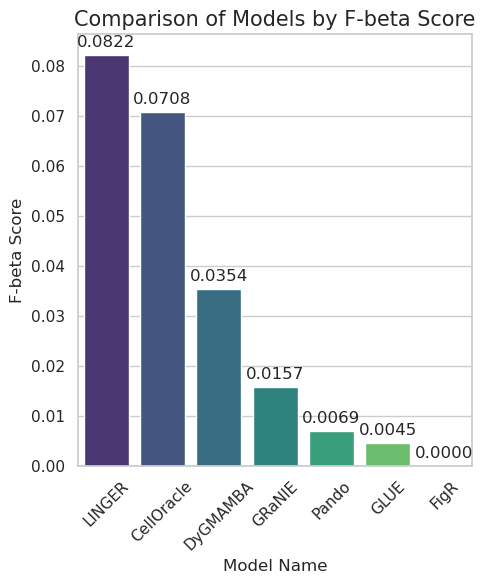

In [158]:
from analysis.assess import glue_read_full_grn
from data_preprocess import adata_to_dataframe


##############################################################################################
# ************************ Benchmark Data **************
data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/"

benchmark_tf_gene_grn = ad.read_h5ad(data_path + "process/tf_gene_network.h5ad")
    
benchmark_tf_gene_df = adata_to_dataframe(benchmark_tf_gene_grn)

benchmark_tf_gene_df = benchmark_tf_gene_df.rename(columns= {"obs":"TF", "var":"Gene"})

benchmark_tf_gene_threshold = benchmark_tf_gene_df["value"].quantile(0.25)

benchmark_tf_gene_df["label"] = (benchmark_tf_gene_df["value"] > benchmark_tf_gene_threshold).astype(int)

benchmark_tf_gene_df.drop_duplicates(subset=['TF', 'Gene'], inplace=True)
##########################################################################
# dyg TF-Gene predictability

dyg_result_path = data_path + "data_dyg/"
avg_active_tf_gene_df = pd.read_pickle(dyg_result_path + "average_active_tf_gene_grn.pkl")
avg_global_tf_gene_df = pd.read_pickle(dyg_result_path + "average_global_tf_gene_grn.pkl")

dyg_active_tf_gene_grn = avg_active_tf_gene_df[["TF","Gene","avg_total_weight"]].copy()
dyg_active_tf_gene_grn["predict_label"] = (dyg_active_tf_gene_grn["avg_total_weight"]>1).astype(int)
dyg_active_tf_gene_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)

##########################################################################
# GLUE TF-Gene predictability
glue_data_path = data_path + "data_glue/"
glue_df = glue_read_full_grn(glue_data_path + 'pruned_grn.csv')
glue_df = glue_df[['TF', 'Target', 'Importance', 'MotifID', 'NES', 'AUC', 'RankAtMax', 'MotifSimilarityQvalue', 'Annotation']]

glue_grn = glue_df[["TF","Target","Importance"]].rename(columns = {"Target":"Gene"})
glue_grn['predict_label'] = (glue_grn["Importance"]>0).astype(int)
glue_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)

##########################################################################
# FigR TF-Gene predictability

figr_df = pd.read_csv(data_path + "data_FigR/TF_Gene_Network.csv")
figr_grn = figr_df[["TF","Target_Gene", "Correlation"]].copy()
figr_grn.rename(columns={"Target_Gene": "Gene", "Correlation":"score"}, inplace=True)
figr_grn["score"] = abs(figr_grn["score"])
figr_grn["predict_label"] = (figr_grn["score"]>0).astype(int)
figr_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)


##########################################################################
# Celloracle TF-Gene predictability

celloracle_df = pd.read_csv(data_path + "data_celloracle/celloracle_results/grn_df_" + "cluster0" + ".csv")
celloracle_df.rename(columns={"source": "TF", "target": "Gene"}, inplace= True)

celloracle_grn = celloracle_df[["TF", "Gene", "coef_abs"]].copy()
celloracle_grn.rename(columns={"coef_abs": "score"}, inplace=True)
celloracle_grn["predict_label"] = (celloracle_grn["score"]>0).astype(int)
celloracle_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)



##########################################################################
# LINGER TF-Gene predictability

linger_df = pd.read_csv(data_path + "data_linger/train/cell_population_trans_regulatory.txt", sep='\t')
linger_df = linger_df.rename(columns={'Unnamed: 0': 'Gene'})
linger_df= linger_df.melt(id_vars=['Gene'], var_name='TF', value_name='regulation')
linger_df.rename(columns={"regulation": "score"}, inplace=True)

linger_grn = linger_df[["TF", "Gene", "score"]].copy()
quantile_value = linger_grn["score"].quantile(0.25)
linger_grn["predict_label"] = (linger_grn["score"] > quantile_value).astype(int)
linger_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)

##########################################################################
# GRaNIE TF-Gene predictability

granie_df = pd.read_csv(data_path + "GRaNIE_output/GRaNIE_tf_gene_Links.csv")
granie_df.dropna()
granie_df["score"] = granie_df["TF_peak.r"].abs()* granie_df['peak_gene.r'].abs()

granie_grn = granie_df[["TF.name", "gene.name", "score"]].copy()
granie_grn.rename(columns={"TF.name": "TF", "gene.name": "Gene"}, inplace=True)
granie_grn_quantile = granie_grn["score"].quantile(0.25)
granie_grn["predict_label"] = (granie_grn["score"] > granie_grn_quantile).astype(int)
granie_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)


##########################################################################
# Pando TF-Gene predictability

pando_df = pd.read_csv(data_path + "data_pando/tf_gene_network.csv")
pando_df["predict_label"] = (pando_df["padj"]<0.04).astype(int)

pando_grn = pando_df[["TF", "Gene", "predict_label"]].copy()
pando_grn.drop_duplicates(subset=['TF', 'Gene'], inplace=True)


##########################################################################
# result
from analysis.assess import each_confusion_matrix
from analysis.assess import manual_assess

model_dict = {"DyGMAMBA": dyg_active_tf_gene_grn, "GLUE": glue_grn, "FigR": figr_grn,
              "Pando": pando_grn, "CellOracle": celloracle_grn, "LINGER": linger_grn, "GRaNIE": granie_grn}

result_list = []
for model_name, model_df in model_dict.items():
    merged_data = pd.merge(benchmark_tf_gene_df, model_df, on = ["TF", "Gene"], how="outer").fillna(0)
    y_true = merged_data["label"]
    y_pred = merged_data["predict_label"]
    TN, FP, FN, TP = each_confusion_matrix(y_true, y_pred)
    precision, recall, FPR, AUC, f_beta = manual_assess(TN, FP, FN, TP, beta = 0.1 )
    result_list.append({
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "FPR": FPR,
        "AUC": AUC,
        "F-beta": f_beta
    })
    print(f"{model_name} - Precision: {precision:.4f}, Recall: {recall:.4f}, FPR: {FPR:.4f}, AUC: {AUC:.4f}, F-beta: {f_beta:.4f}")

result_dataframe = pd.DataFrame(result_list)

##########################################################################
# figure plot

sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 6))

# 3. 绘制条形图
# 按照 F-beta 从高到低排序会让图表更有说服力
ax = sns.barplot(x='Model', y='F-beta', data=result_dataframe.sort_values('F-beta', ascending=False), palette='viridis')

# 4. 添加细节
plt.title('Comparison of Models by F-beta Score', fontsize=15)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('F-beta Score', fontsize=12)
plt.xticks(rotation=45) # 防止模型名称太长重叠

# 在柱状图上方标注具体数值
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()


/tmp/ipykernel_105301/922309804.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Precision', data=result_dataframe.sort_values('Precision', ascending=False), palette='viridis')


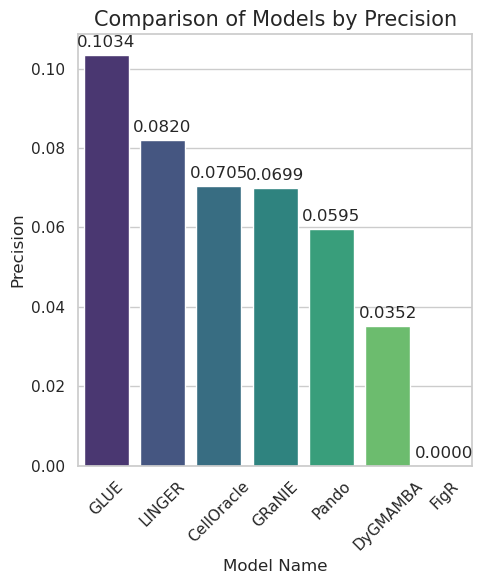

In [160]:
##########################################################################
# figure plot

sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 6))

# 3. 绘制条形图
# 按照 F-beta 从高到低排序会让图表更有说服力
ax = sns.barplot(x='Model', y='Precision', data=result_dataframe.sort_values('Precision', ascending=False), palette='viridis')

# 4. 添加细节
plt.title('Comparison of Models by Precision', fontsize=15)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xticks(rotation=45) # 防止模型名称太长重叠

# 在柱状图上方标注具体数值
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

# Other TF-Region

In [1]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import dill

import networkx as nx
# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2


sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

from pdata.data_preprocess import filter_jaspar_tf, adata_to_dataframe
from pdata.data_preprocess import build_tf_peak_network
from analysis.assess_tf_region import calculate_tf_metrics


## Benchmark

In [ ]:
f_score = 0.1

data_root = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/process/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/benchmark/"

unibind_df_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/benchmark/unibind_df.pkl"

os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(data_path + "atac_processed.h5ad")

##################################################################
# Benchmark TF-Region
# 读取整个文件
tf_chip_seq = pd.read_parquet(data_path + "combined_chip_seq.parquet")
cell_type_chip_seq = tf_chip_seq[["chrom", "start", "end", "tf_name"]].copy()
cell_type_chip_seq.rename(columns={'tf_name':'tf'},inplace = True)
cell_type_chip_seq = cell_type_chip_seq[['tf','chrom','start','end']].copy()

unibind_df = pd.read_pickle(unibind_df_file)
unibind_chip_df = unibind_df[unibind_df['TF'].isin(set(cell_type_chip_seq["tf"]))].copy()

unibind_chip_df = unibind_chip_df[["chrom", "start", "end", "TF"]].copy()
unibind_chip_df.rename(columns={'TF':'tf'},inplace = True)
unibind_chip_df = unibind_chip_df[['tf','chrom','start','end']].copy()

unibind_tf_peak = build_tf_peak_network(adata_atac, unibind_chip_df)
unibind_tf_peak_grn = adata_to_dataframe(unibind_tf_peak)
unibind_tf_peak_grn.rename(columns={'obs':'peak_id', "var":"tf"},inplace = True)
unibind_tf_peak_grn[['chrom', 'start', 'end']] = unibind_tf_peak_grn['peak_id'].str.split('-', expand=True)
unibind_tf_peak_grn['start'] = unibind_tf_peak_grn['start'].astype(int)
unibind_tf_peak_grn['end'] = unibind_tf_peak_grn['end'].astype(int)
unibind_tf_peak_grn.rename(columns={'tf':'TF'},inplace = True)

####################################################################
# dyg TF-Region
jaspar_tf_region_file = data_path + "jaspar_data_processed.h5ad"
jaspar_data = ad.read_h5ad(jaspar_tf_region_file)
adata_region_tf = filter_jaspar_tf(jaspar_data)

coo_matrix = adata_region_tf.X.tocoo()
tf_peak_df = pd.DataFrame({
    'Peak': adata_region_tf.obs_names[coo_matrix.row],
    'TF': adata_region_tf.var_names[coo_matrix.col],
    'value': coo_matrix.data
})
tf_peak_df = tf_peak_df[tf_peak_df["TF"].isin(set(adata_rna.var_names))]
tf_peak_df = tf_peak_df[tf_peak_df["Peak"].isin(set(adata_atac.var_names))]

dyg_results = calculate_tf_metrics(tf_peak_df, unibind_tf_peak_grn, f_beta = f_score)

# dyg_results.to_csv(output_path + "dyg_tf_region_jaspar_unibind_results.csv", index=False)

####################################################################
# GLUE TF-Region

glue_data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/data_glue/"
with open(glue_data_path + "peak2tf.pkl", "rb") as f:
    tf_peak_nx = dill.load(f)
glue_tf_peak_df = nx.to_pandas_edgelist(tf_peak_nx) 
glue_tf_peak_df["value"] = 1
glue_tf_peak_df.rename(columns={'source':'Peak', 'target':'TF'}, inplace=True)

glue_results = calculate_tf_metrics(glue_tf_peak_df, unibind_tf_peak_grn, f_beta = f_score)
print("*"*20 + " GLUE " + "*"*20)
print(glue_results)

##########################################################################
# LINGER TF-Region predictability

linger_grn = pd.read_csv(data_root + "data_linger/train/cell_population_TF_RE_binding.txt", sep='\t')
linger_grn = linger_grn.rename(columns={'Unnamed: 0': 'Peak'})
linger_df= linger_grn.melt(id_vars=['Peak'], var_name='TF', value_name='regulation')
if linger_df['Peak'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    linger_df['Peak'] = linger_df['Peak'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")
    
linger_results = calculate_tf_metrics(linger_df, unibind_tf_peak_grn, f_beta = f_score)


##########################################################################
# GRaNIE TF-Region predictability

granie_grn = pd.read_csv(data_root + "GRaNIE_output/GRaNIE_tf_region_Links.csv")

granie_df = granie_grn[["TF.name", "peak.ID", "TF_peak.r", "TF_peak.fdr"]].copy()
granie_df.rename(columns={"TF.name": "TF", "peak.ID": "Peak"}, inplace=True)

if granie_df['Peak'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    granie_df['Peak'] = granie_df['Peak'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")
    
granie_results = calculate_tf_metrics(granie_df, unibind_tf_peak_grn, f_beta = f_score)


##########################################################################
# Pando TF-Region predictability

pando_grn = pd.read_csv(data_root + "data_pando/tf_region_network.csv")

pando_df = pando_grn.copy()
pando_df.rename(columns={"Region": "Peak"}, inplace=True)

if pando_df['Peak'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    pando_df['Peak'] = pando_df['Peak'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")
    
pando_results = calculate_tf_metrics(pando_df, unibind_tf_peak_grn, f_beta = f_score)

dyg_results['Method'] = 'DYG'
glue_results['Method'] = 'GLUE'
linger_results['Method'] = 'LINGER'
granie_results['Method'] = 'GRaNIE'
pando_results['Method'] = 'Pando'


--- 1. 准备 ATAC Peak 数据 ---
未提供过滤列表，将使用 atac_adata 中所有的 Peaks。
ATAC Peaks 数量: 31555
--- 2. 准备 TF ChIP 数据 ---
TF ChIP Peaks 数量: 2662899
--- 3. 计算重叠 (构建 Network) ---
构建了包含 270321 条边的 TF-Peak 网络。
--- 4. 转换为矩阵 (Matrix Construction) ---
--- 5. 封装为 AnnData ---
✅ 完成！生成的 AnnData 维度: (31555, 48) (Peaks x TFs)

步骤 1: 过滤 Peaks (行)
  > 找到 68947 / 68947 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 850 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (68947, 850)
正在解析 Consensus Peaks 坐标...
共发现 41 个共有 TF，开始评估...
正在解析 Consensus Peaks 坐标...
共发现 7 个共有 TF，开始评估...
******************** GLUE ********************
      TF  Precision    Recall        F1   TP   FP    FN  GroundTruth_Count  \
0   ATF7   0.871795  0.266667  0.206246   68   10   187                255   
1   USF1   0.853659  0.194878  0.160245  175   30   723                898   
2  HNF4A   0.878694  0.203824  0.167101  565   78  2207               2772   
3   IRF3   0.013761  0.034483  0.009934    3  215    84                 87   
4  FOXA1   0.926829  0

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_n_comparison(method_dict, top_n=200, score_col="Precision", palette="Set2"):
    """
    对比多种方法表现最好的前 N 个基因。
    
    参数:
    :param method_dict: 字典，Key 为方法名 (str), Value 为对应的 DataFrame。
    :param top_n: 取前多少个基因进行对比 (int)。
    :param score_col: 用于排序和评价的列名 (str)，如 "Precision", "Spearman_Rho", "F1"。
    :param palette: 绘图配色方案。
    """
    
    combined_list = []
    
    for method_name, df in method_dict.items():
        # 1. 检查列名是否存在
        if score_col not in df.columns:
            print(f"跳过方法 {method_name}: 找不到列 '{score_col}'")
            continue
            
        # 2. 排序并提取前 N 个
        # 深拷贝一份以防修改原始数据，并按降序排序
        temp_df = df.sort_values(by=score_col, ascending=False).head(top_n).copy()
        
        # 3. 添加必要的信息
        temp_df['Method'] = method_name
        temp_df['Rank'] = range(1, len(temp_df) + 1)
        
        combined_list.append(temp_df[['Method', score_col, 'Rank']])
    
    if not combined_list:
        print("错误: 没有有效的数据可以绘制。")
        return None
        
    # 4. 合并所有数据
    df_plot = pd.concat(combined_list)
    
    # ==========================================
    # 5. 开始绘图
    # ==========================================
    sns.set_theme(style="ticks")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 计算排序逻辑（按中位数从高到低排列箱线图）
    order = df_plot.groupby('Method')[score_col].median().sort_values(ascending=False).index
    
    # --- 图 1: Top N 分布对比 (Boxplot) ---
    sns.boxplot(data=df_plot, x='Method', y=score_col, 
                order=order, palette=palette, width=0.6, ax=ax1)
    sns.stripplot(data=df_plot, x='Method', y=score_col, 
                  order=order, color='black', size=2, alpha=0.3, jitter=True, ax=ax1)
    
    ax1.set_title(f"Top {top_n} Genes: {score_col} Distribution", fontsize=14)
    ax1.set_ylabel(score_col)
    ax1.set_xlabel("")
    ax1.tick_params(axis='x', rotation=45)

    # --- 图 2: 性能衰减曲线 (Line Plot) ---
    sns.lineplot(data=df_plot, x='Rank', y=score_col, 
                 hue='Method', hue_order=order, palette=palette, lw=2.5, ax=ax2)
    
    ax2.set_title(f"Top {top_n} Genes: {score_col} Decay Curve", fontsize=14)
    ax2.set_xlabel("Gene Rank (Sorted by score)")
    ax2.set_ylabel(score_col)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    sns.despine()
    plt.show()
    
    return df_plot # 返回处理后的数据，方便后续查阅

/tmp/ipykernel_105301/1780579024.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


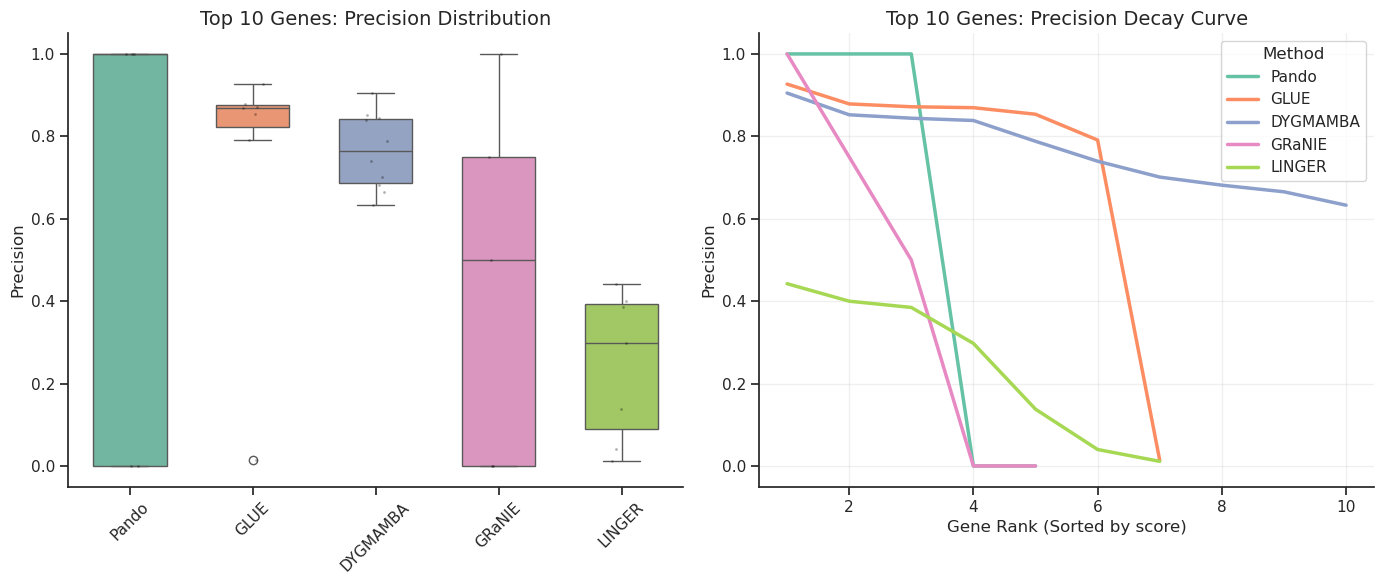

In [75]:
# 1. 准备数据字典
my_methods = {
    "DYGMAMBA": dyg_results,
    "GLUE": glue_results,
    "LINGER": linger_results,
    "GRaNIE": granie_results,
    "Pando": pando_results
}

# 2. 调用函数
# 例如：对比前 200 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict=my_methods, 
    top_n=10, 
    score_col="Precision"
)

/tmp/ipykernel_105301/1780579024.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,


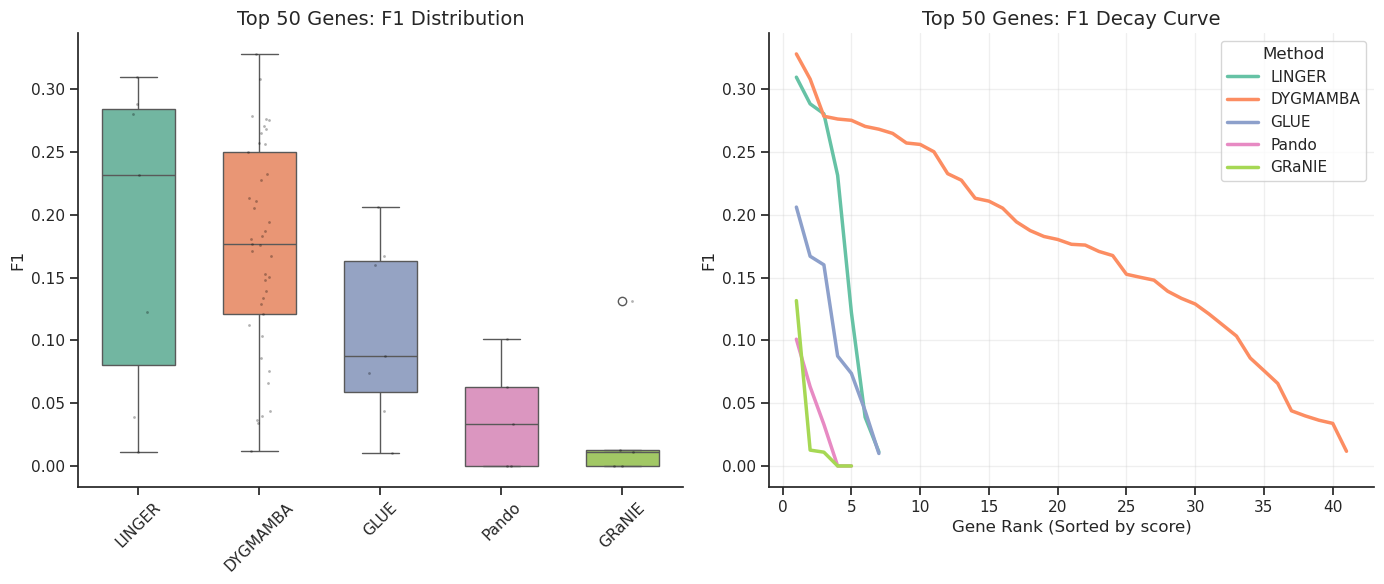

In [79]:
# 2. 调用函数
# 例如：对比前 200 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict=my_methods, 
    top_n=50, 
    score_col="F1"
)

## Precision

/tmp/ipykernel_105301/1831672377.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,


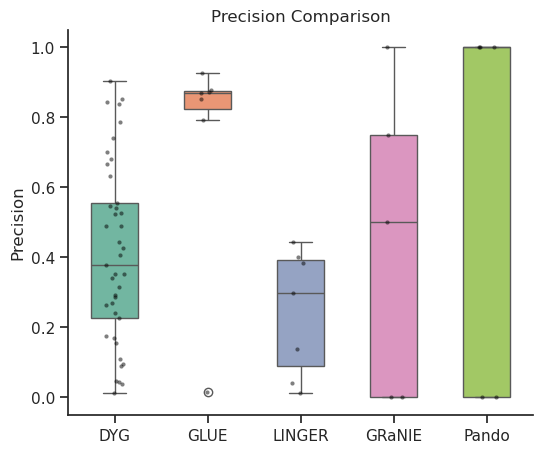

In [10]:
analysis_type = "Precision"

# 拼接在一起 (只取 F1 和 Method 列)
df_combined = pd.concat([dyg_results[[analysis_type, 'Method']], 
                         glue_results[[analysis_type, 'Method']],
                         linger_results[[analysis_type, 'Method']],
                         granie_results[[analysis_type, 'Method']],
                         pando_results[[analysis_type, 'Method']]])

# ==========================================
# 3. 绘制箱形图
# ==========================================
# 设置绘图风格
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

# 画图
ax = sns.boxplot(data=df_combined, 
                 x='Method',    # x轴放分组标签
                 y=analysis_type,        # y轴放数值
                 palette="Set2", # 配色方案
                 width=0.5)     # 箱子宽度

# (可选) 添加抖动散点，展示原始数据点分布
sns.stripplot(data=df_combined, x='Method', y=analysis_type, 
              color='black', size=3, alpha=0.5, jitter=True)

# ==========================================
# 4. 美化与保存
# ==========================================
plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

# 保存图片
# plt.savefig("f1_boxplot_comparison.pdf", bbox_inches='tight')
plt.show()

## F1 score

/tmp/ipykernel_105301/3221341252.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,


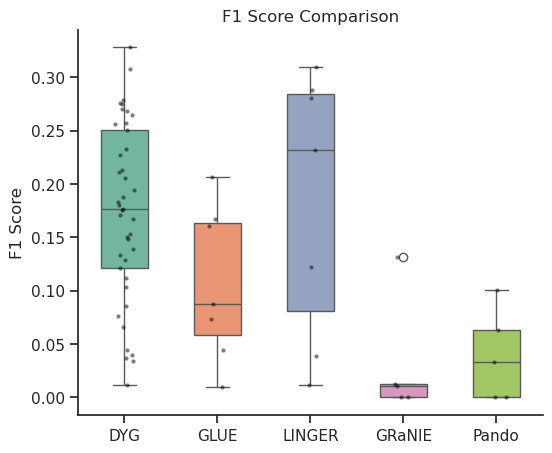

In [11]:

# 拼接在一起 (只取 F1 和 Method 列)
df_combined = pd.concat([dyg_results[['F1', 'Method']], 
                         glue_results[['F1', 'Method']],
                         linger_results[['F1', 'Method']],
                         granie_results[['F1', 'Method']],
                         pando_results[['F1', 'Method']]])

# ==========================================
# 3. 绘制箱形图
# ==========================================
# 设置绘图风格
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

# 画图
ax = sns.boxplot(data=df_combined, 
                 x='Method',    # x轴放分组标签
                 y='F1',        # y轴放数值
                 palette="Set2", # 配色方案
                 width=0.5)     # 箱子宽度

# (可选) 添加抖动散点，展示原始数据点分布
sns.stripplot(data=df_combined, x='Method', y='F1', 
              color='black', size=3, alpha=0.5, jitter=True)

# ==========================================
# 4. 美化与保存
# ==========================================
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

# 保存图片
# plt.savefig("f1_boxplot_comparison.pdf", bbox_inches='tight')
plt.show()

# Other Region-Gene

## Benchmark

In [45]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import dill
import networkx as nx
import seaborn as sns

sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')


from pdata.data_preprocess import adata_to_dataframe
from benchmark.benchmark_process import Region_Gene_Benchmark

# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2



from analysis.assess_region_gene import evaluate_per_gene_correlation, evaluate_scenic_plus_correlation, region_gene_evaluate

data_root = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/"

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/process/"

output_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/benchmark/"

unibind_df_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/benchmark/unibind_df.pkl"

model_result_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/data_dyg/"

os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(data_path + "atac_processed.h5ad")
adata_rna = ad.read_h5ad(data_path + "rna_processed.h5ad")
total_peak = set(adata_atac.var_names)
total_gene = set(adata_rna.var_names)

##################################################################
benchmark_peak_gene_df = pd.read_pickle(data_path + "peak_gene_df.pkl")
benchmark_peak_gene_df = benchmark_peak_gene_df.rename(columns= {"PeakID":"Peak", "gene_name":"Gene","hic_score":"value"})
benchmark_peak_gene_df["label"] = (benchmark_peak_gene_df["value"]>0).astype(int)
benchmark_peak_gene_df = benchmark_peak_gene_df[benchmark_peak_gene_df["Peak"].isin(total_peak)].copy()
benchmark_peak_gene_df = benchmark_peak_gene_df[benchmark_peak_gene_df["Gene"].isin(total_gene)].copy()

df_hic = benchmark_peak_gene_df.copy()
df_hic = df_hic.rename(columns={"Peak":"region", "Gene":"gene"})

############################################################################################

Markrer_Genes = adata_rna.var["highly_variable_rank"].copy()
Markrer_Genes = Markrer_Genes.sort_values()
top_marker_genes = list(Markrer_Genes.index[:100])

############################################################################################
# DYGMAMBA peak-gene grn
    
Node_id = pd.read_pickle(model_result_path + "node_id.pkl")
graph_df = pd.read_pickle(model_result_path + "Graph_df.pkl")
graph_df["Unnamed"] = graph_df.index
name_list = ["Unnamed", "source_node", "target_node", "time", "label", "edge_idx"]
New_Graph = graph_df[name_list].copy()
New_Graph.columns = ['Unnamed: 0', 'u', 'i', 'ts', 'label', 'idx']

result_path = model_result_path + 'my_result_run0.npy'
predict_edge_label = np.load(result_path)

# binary_output = (predict_edge_label > 0.5).astype(int)
New_Graph["predict"] = predict_edge_label
dyg_predict_grn = New_Graph.copy()

mapping_series = Node_id["name"]
dyg_predict_grn['source'] = (dyg_predict_grn['u'] - 1).map(mapping_series)
dyg_predict_grn['target'] = (dyg_predict_grn['i'] - 1).map(mapping_series)

dyg_peak_gene_df = dyg_predict_grn[['source', 'target', 'ts','predict']].rename(
    columns={'source': 'Peak', 'target': 'Gene'}
)
dyg_peak_gene_df = dyg_peak_gene_df[~dyg_peak_gene_df["Gene"].str.startswith('chr')].copy()
    
####################################################################################

avg_active_peak_gene_grn = dyg_peak_gene_df.groupby(['Peak', 'Gene']).agg(
    avg_ts_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()
avg_active_peak_gene_grn = avg_active_peak_gene_grn[avg_active_peak_gene_grn["Peak"].isin(total_peak)].copy()

avg_active_peak_gene_grn["predict"] = (avg_active_peak_gene_grn["avg_ts_weight"]> 0.9).astype(int)

avg_active_peak_gene_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)
avg_active_peak_gene_grn.dropna()

df_pred = avg_active_peak_gene_grn.copy()
df_pred = df_pred.rename(columns={"Peak":"region", "Gene":"gene", "avg_ts_weight":"value"})
avg_active_peak_gene_grn["value"] = avg_active_peak_gene_grn["avg_ts_weight"]

dyg_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, avg_active_peak_gene_grn, 
                                            model_name="DYGMAMBA", output_path=output_path)

dyg_corr_score, dyg_plot_data = evaluate_scenic_plus_correlation(df_pred, df_hic, 
                                                            marker_genes=top_marker_genes)
print("*"*50)
print("*"*20 + " DYGMAMBA " + "*"*20)
print(dyg_corr_score)
print("*"*50)
print(dyg_results)
print("*"*50)
print(dyg_peak_gene_result)
#######################################################################################
#
#
#######################################################################################
# GLUE peak-gene grn

glue_data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/data_glue/"

with open(glue_data_path + "gene2peak.pkl", "rb") as f:
    gene_peak_nx = dill.load(f)
glue_gene_peak_df = nx.to_pandas_edgelist(gene_peak_nx)

glue_gene_peak_df.drop_duplicates(subset=["source", "target"], inplace=True)
glue_gene_peak_df.rename(columns={'source':'Gene', 'target':'Peak', 'weight':'predict'}, inplace=True)
glue_gene_peak_df["predict"] = (glue_gene_peak_df["predict"]>0.9).astype(int)
glue_gene_peak_df["value"] = glue_gene_peak_df["score"]
glue_pred = glue_gene_peak_df[["Peak", "Gene", "value"]].copy()
glue_pred = glue_pred.rename(columns={"Peak":"region", "Gene":"gene"})

glue_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, glue_gene_peak_df, 
                                            model_name="GLUE", output_path=output_path)  

glue_corr_score, glue_plot_data = evaluate_scenic_plus_correlation(glue_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# Pando peak-gene grn

pando_grn = pd.read_csv(data_root + "data_pando/region_gene_network.csv")
pando_grn.drop_duplicates(subset=["Region", "Gene"], inplace=True)
pando_grn.dropna()
pando_gene_peak_df = pando_grn.copy()
pando_gene_peak_df.rename(columns={"Region": "Peak"}, inplace=True)
pando_gene_peak_df["predict"] = (pando_gene_peak_df["padj"]<0.05).astype(int)
pando_gene_peak_df["value"] = -np.log10(pando_gene_peak_df["padj"])
pando_pred = pando_gene_peak_df[["Peak", "Gene", "value"]].copy()
pando_pred = pando_pred.rename(columns={"Peak":"region", "Gene":"gene"})

pando_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, pando_gene_peak_df, 
                                            model_name="Pando", output_path=output_path)  

pando_corr_score, pando_plot_data = evaluate_scenic_plus_correlation(pando_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)



#######################################################################################
# FigR peak-gene grn
figr_grn = pd.read_csv(data_root + "data_FigR/Region_Gene_Network.csv")
if figr_grn['Region'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    figr_grn['Region'] = figr_grn['Region'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")

figr_grn.drop_duplicates(subset=["Region", "Target_Gene"], inplace=True)

figr_gene_peak_df = figr_grn.copy()
figr_gene_peak_df.rename(columns={"Region": "Peak", "Target_Gene":"Gene"}, inplace=True)
figr_gene_peak_df["predict"] = (figr_gene_peak_df["P_Value"]<0.05).astype(int)
figr_gene_peak_df["value"] = figr_gene_peak_df["Correlation"]

figr_pred = figr_gene_peak_df[["Peak", "Gene", "value"]].copy()
figr_pred = figr_pred.rename(columns={"Peak":"region", "Gene":"gene"})

figr_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, figr_gene_peak_df, 
                                            model_name="FigR", output_path=output_path)  

figr_corr_score, figr_plot_data = evaluate_scenic_plus_correlation(figr_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# LINGER peak-gene grn

linger_grn = pd.read_csv(data_root + "data_linger/train/cell_population_cis_regulatory.txt", 
                         sep='\t', header=None, names=["Peak", "Gene", "reg"])

if linger_grn['Peak'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    linger_grn['Peak'] = linger_grn['Peak'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")

linger_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)

linger_gene_peak_df = linger_grn.copy()
linger_gene_peak_df["predict"] = (linger_gene_peak_df["reg"]<0.05).astype(int)
linger_gene_peak_df["value"] = -np.log10(linger_gene_peak_df["reg"])

linger_pred = linger_gene_peak_df[["Peak", "Gene", "value"]].copy()
linger_pred = linger_pred.rename(columns={"Peak":"region", "Gene":"gene"})

linger_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, linger_gene_peak_df, 
                                            model_name="LINGER", output_path=output_path)

linger_corr_score, linger_plot_data = evaluate_scenic_plus_correlation(linger_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# GRaNIE peak-gene grn

granie_grn = pd.read_csv(data_root + "GRaNIE_output/GRaNIE_region_gene_Links.csv")

if granie_grn['peak.ID'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    granie_grn['peak.ID'] = granie_grn['peak.ID'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")
granie_grn.dropna()

granie_grn = granie_grn.rename(columns={"peak.ID":"Peak", "gene.name":"Gene"})
granie_grn.dropna()
granie_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)

granie_gene_peak_df = granie_grn.copy()

granie_gene_peak_df["predict"] = 1
granie_gene_peak_df["value"] = -np.log10(granie_gene_peak_df["peak_gene.p_adj"])

granie_pred = granie_gene_peak_df[["Peak", "Gene", "value"]].copy()
granie_pred = granie_pred.rename(columns={"Peak":"region", "Gene":"gene"})

granie_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, granie_gene_peak_df, 
                                            model_name="GRaNIE", output_path=output_path)

granie_corr_score, granie_plot_data = evaluate_scenic_plus_correlation(granie_pred, df_hic,
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# results analysis

results = pd.DataFrame({"GRaNIE":abs(granie_corr_score), "FigR":abs(figr_corr_score), 
                        "LINGER":abs(linger_corr_score), "Pando":abs(pando_corr_score), 
                        "GLUE":abs(glue_corr_score), "DYGMAMBA":abs(dyg_corr_score)}, index=[0])



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))


**************************************************
merged: 9907, benchmark peak gene: 10381,        dyg peak gene 50006
Peak-Gene: 3969,         1827, edge:9907
Merged Peak-Gene: 3969, 1827,         9907
DYGMAMBA Peak-Gene: 30814, 1999,         edge: 50006
Benchmark Peak-Gene: 4125,         1836, edge: 10381
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 499 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = 0.0020 (P-value = 9.64e-01)
**************************************************
******************** DYGMAMBA ********************
0.0020060994734726746
**************************************************
         TF  Precision    Recall        F1     TP     FP     FN  \
0      ATF7   0.425829  0.634315  0.257334    732    987    422   
1      REST   0.225561  0.628452  0.167646   2845   9768   1682   
2     NR2F2   0.340586  0.359382  0.176614   1628   3152   2902   
3     FOXK2   0.240340  0.407849  0.152737    821   2595

/home/liyang/BioWuYan/conda_env/dygmamba39/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))


## Average score

/tmp/ipykernel_105301/887964530.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')


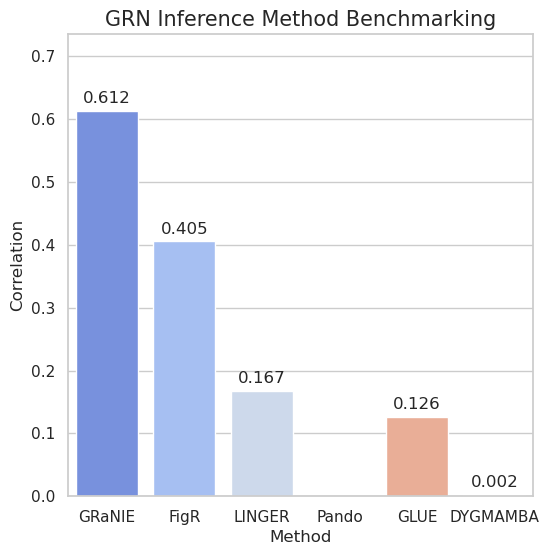

In [46]:
plot_data = results.T.reset_index()
plot_data.columns = ['Method', 'Correlation']

# 2. 绘图
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid") # 设置清爽的白色网格背景

# 使用你喜欢的配色，比如 'viridis' 或 'magma'
ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')

# 在柱子上方自动添加数值标签
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title("GRN Inference Method Benchmarking", fontsize=15)
plt.ylim(0, max(plot_data['Correlation']) * 1.2) # 给上方数值留点空间
plt.show()

## Top score

/tmp/ipykernel_105301/2610393253.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])
/tmp/ipykernel_105301/2610393253.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()
/tmp/ipykernel_105301/2610393253.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])


                       Peak    Gene  value_bench  label  value_method
0    chr1-54052617-54053972  TMEM59   436.092438      1           0.0
1    chr1-40691458-40692708    NFYC   376.581635      1           0.0
2  chr1-235327622-235329293  ARID4B   477.807190      1           0.0
3  chr1-156371500-156372314    RHBG   513.459351      1           0.0
4    chr1-44799786-44800634  BTBD19    94.055214      1           0.0


/tmp/ipykernel_105301/2610393253.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()


                       Peak    Gene  value_bench  label  value_method
0    chr1-54052617-54053972  TMEM59   436.092438      1           0.0
1    chr1-40691458-40692708    NFYC   376.581635      1           0.0
2  chr1-235327622-235329293  ARID4B   477.807190      1           0.0
3  chr1-156371500-156372314    RHBG   513.459351      1           0.0
4    chr1-44799786-44800634  BTBD19    94.055214      1           0.0


/tmp/ipykernel_105301/2610393253.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()
/tmp/ipykernel_105301/2610393253.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])
/tmp/ipykernel_105301/2610393253.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupb

                       Peak    Gene  value_bench  label  value_method
0    chr1-54052617-54053972  TMEM59   436.092438      1      0.993317
1    chr1-40691458-40692708    NFYC   376.581635      1      0.943639
2  chr1-235327622-235329293  ARID4B   477.807190      1      0.943211
3  chr1-156371500-156372314    RHBG   513.459351      1      0.978276
4    chr1-44799786-44800634  BTBD19    94.055214      1      0.958964
                       Peak    Gene  value_bench  label  value_method
0    chr1-54052617-54053972  TMEM59   436.092438      1           0.0
1    chr1-40691458-40692708    NFYC   376.581635      1           0.0
2  chr1-235327622-235329293  ARID4B   477.807190      1           0.0
3  chr1-156371500-156372314    RHBG   513.459351      1           0.0
4    chr1-44799786-44800634  BTBD19    94.055214      1           0.0


/tmp/ipykernel_105301/2610393253.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()
/tmp/ipykernel_105301/2610393253.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])


                       Peak    Gene  value_bench  label  value_method
0    chr1-54052617-54053972  TMEM59   436.092438      1           0.0
1    chr1-40691458-40692708    NFYC   376.581635      1           0.0
2  chr1-235327622-235329293  ARID4B   477.807190      1           0.0
3  chr1-156371500-156372314    RHBG   513.459351      1           0.0
4    chr1-44799786-44800634  BTBD19    94.055214      1           0.0


/tmp/ipykernel_105301/2610393253.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()


                       Peak    Gene  value_bench  label  value_method
0    chr1-54052617-54053972  TMEM59   436.092438      1      1.722133
1    chr1-40691458-40692708    NFYC   376.581635      1      2.365077
2  chr1-235327622-235329293  ARID4B   477.807190      1      2.162130
3  chr1-156371500-156372314    RHBG   513.459351      1      1.913106
4    chr1-44799786-44800634  BTBD19    94.055214      1      2.705787


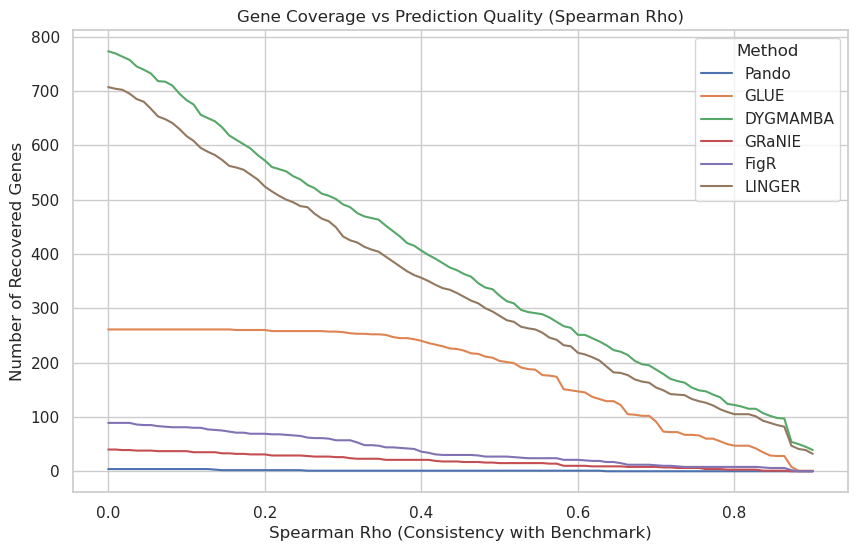

/tmp/ipykernel_105301/2610393253.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_n_df = corr_df.groupby('Method').apply(
/tmp/ipykernel_105301/2610393253.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


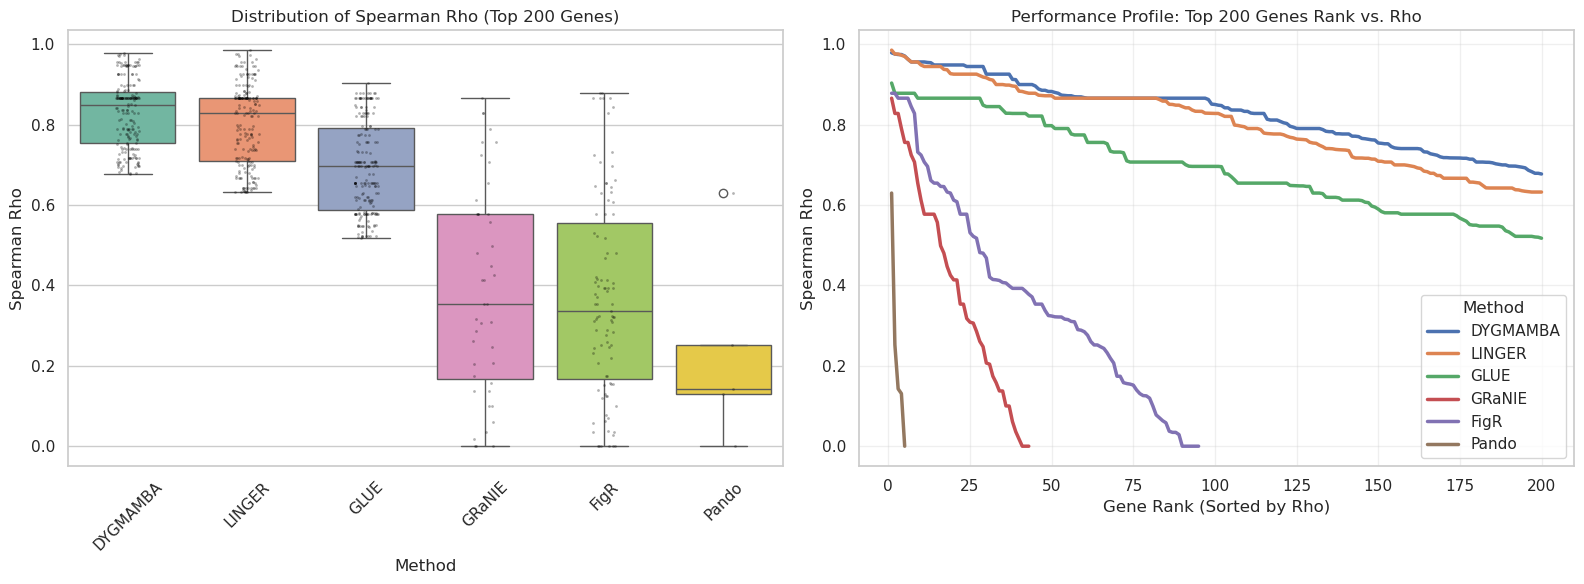

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score


def plot_top_n_methods_comparison(corr_df, top_n=100, compare_method = 'Spearman_Rho'):
    """
    提取每种方法相关性最好的前 N 个基因并进行比较
    :param corr_df: 包含 [Method, Gene, Spearman_Rho] 的 DataFrame
    :param top_n: 每种方法选取的基因数量
    """
    # 1. 提取每种方法的前 N 个基因
    top_n_df = corr_df.groupby('Method').apply(
        lambda x: x.sort_values(compare_method, ascending=False).head(top_n)
    ).reset_index(drop=True)

    # 2. 为绘图计算排名（Rank 1 到 N）
    top_n_df['Rank'] = top_n_df.groupby('Method')[compare_method].rank(
        ascending=False, method='first'
    ).astype(int)

    # 创建画布
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- 图 1: Top N 基因的相关性分布 (Boxplot) ---
    # 这展示了各方法“天花板”的平均水平
    method_order = top_n_df.groupby('Method')[compare_method].median().sort_values(ascending=False).index
    
    sns.boxplot(
        data=top_n_df, x='Method', y=compare_method, 
        order=method_order, palette='Set2', ax=ax1
    )
    sns.stripplot(
        data=top_n_df, 
        x='Method', 
        y=compare_method, 
        order=method_order, 
        color='black', 
        alpha=0.3, 
        size=2, 
        jitter=True,
        ax=ax1
        )
    ax1.set_title(f'Distribution of Spearman Rho (Top {top_n} Genes)')
    ax1.set_ylabel('Spearman Rho')
    ax1.tick_params(axis='x', rotation=45)

    # --- 图 2: Top N 基因的相关性衰减曲线 (Line Plot) ---
    # 这展示了随着排名增加，高质量预测消失的速度
    sns.lineplot(
        data=top_n_df, x='Rank', y=compare_method, 
        hue='Method', hue_order=method_order, lw=2.5, ax=ax2
    )

    ax2.set_title(f'Performance Profile: Top {top_n} Genes Rank vs. Rho')
    ax2.set_xlabel('Gene Rank (Sorted by Rho)')
    ax2.set_ylabel('Spearman Rho')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_recovery_curves(corr_df, compared_method='Spearman_Rho'):
    """
    恢复曲线：X轴是相关性阈值，Y轴是该方法在该质量下能覆盖的基因总数
    """
    thresholds = np.linspace(0, 0.9, 100) # 覆盖从低到高的相关性区间
    plot_list = []
    
    for method in corr_df['Method'].unique():
        m_vals = corr_df[corr_df['Method'] == method][compared_method].values
        for thr in thresholds:
            count = np.sum(m_vals > thr)
            plot_list.append({'Method': method, 'Threshold': thr, 'Gene_Count': count})
            
    pdf = pd.DataFrame(plot_list)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=pdf, x='Threshold', y='Gene_Count', hue='Method')
    plt.title('Gene Coverage vs Prediction Quality (Spearman Rho)')
    plt.ylabel('Number of Recovered Genes')
    plt.xlabel('Spearman Rho (Consistency with Benchmark)')
    plt.show()





def evaluate_r2g_benchmark(benchmark_df, method_dict, min_links=5):
    """
    评估 R2G 预测性能
    :param benchmark_df: 金标准 [Peak, Gene, value, label]
    :param method_dict: 方法字典，如 {'GRaNIE': df1, 'GLUE': df2}
    :param min_links: 每个基因计算相关性所需的最少边数
    """
    correlation_results = []
    global_metrics = []
    
    # 1. 计算每个基因的相关性（关注质量）
    for method_name, pred_df in method_dict.items():
        # 合并预测与金标准
        merged = pd.merge(
            benchmark_df[['Peak', 'Gene', 'value', 'label']], 
            pred_df[['Peak', 'Gene', 'value']], 
            on=['Peak', 'Gene'],
            how='left',
            suffixes=('_bench', '_method')
        )
        merged['value_method'] = merged['value_method'].fillna(0)
        if merged.empty:
            print(f"警告: 方法 {method_name} 与金标准无共有 Peak-Gene 对，跳过。")
            continue
        # 按基因分组计算 Spearman Rho
        def get_gene_cor(group):
            if len(group) < min_links:
                return np.nan
            # 使用预测分值与金标准连续值（如 Hi-C score）计算相关性
            rho, _ = spearmanr(group['value_bench'], group['value_method'])
            return rho

        gene_rhos = merged.groupby('Gene').apply(get_gene_cor).dropna()
        
        for gene, rho in gene_rhos.items():
            correlation_results.append({
                'Method': method_name,
                'Gene': gene,
                'Spearman_Rho': rho
            })
        print(merged.head())
        try:
            auprc = average_precision_score(merged['label'], merged['value_method'])
            global_metrics.append({
                'Method': method_name, 
                'AUPRC': auprc, 
                'Total_Links': len(pred_df),
                'Common_Links': len(merged)
            })
        except Exception as e:
            print(f"计算 {method_name} 的 AUPRC 时出错: {e}")
            

    corr_df = pd.DataFrame(correlation_results)
    metrics_df = pd.DataFrame(global_metrics)
    
    return corr_df, metrics_df



###########################################
# 
method_data = {"Pando":pando_gene_peak_df, "GLUE":glue_gene_peak_df, "DYGMAMBA":avg_active_peak_gene_grn,
               "GRaNIE":granie_gene_peak_df, "FigR":figr_gene_peak_df, "LINGER":linger_gene_peak_df}
corr_df, metrics_df = evaluate_r2g_benchmark(benchmark_peak_gene_df, method_data)


# 使用示例：
# 假设 top_n=200，比较各方法最准的 200 个基因
corr_df['Abs_Spearman_Rho'] = corr_df['Spearman_Rho'].abs()

# 调用
plot_recovery_curves(corr_df, compared_method='Abs_Spearman_Rho')

plot_top_n_methods_comparison(corr_df, top_n=200, compare_method='Abs_Spearman_Rho')

# TEST

In [2]:
import sys
import os
import pickle
import pandas as pd
import anndata as ad
import numpy as np
import seaborn as sns
import networkx as nx
from tqdm import tqdm
import scipy.sparse
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

from analysis.assess_tf_recovery import calculate_recovery_metrics
from analysis.assess_tf_gene import evaluate_predictability
from analysis.assess_tf_region import calculate_tf_metrics

from pdata.benchmark_data import glue_read_ctx_grn

from pdata.data_preprocess import filter_jaspar_tf, adata_to_dataframe
from pdata.data_preprocess import build_tf_peak_network
from pdata.data_read import read_unibind_file
from analysis.assess_region_gene import evaluate_per_gene_correlation, evaluate_scenic_plus_correlation
from analysis.assess_region_gene import region_gene_evaluate
import dill

In [33]:
data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/HepG2/"

output_path = data_path + "benchmark/"

os.makedirs(output_path, exist_ok=True )

adata_atac = ad.read_h5ad(data_path + "process/atac_processed.h5ad")
adata_rna = ad.read_h5ad(data_path + "process/rna_processed.h5ad")
total_peak = set(adata_atac.var_names)
total_gene = set(adata_rna.var_names)

##################################################################
benchmark_peak_gene_df = pd.read_pickle(data_path + "process/peak_gene_df.pkl")
benchmark_peak_gene_df = benchmark_peak_gene_df.rename(columns= {"PeakID":"Peak", "gene_name":"Gene","hic_score":"value"})
benchmark_peak_gene_df["label"] = (benchmark_peak_gene_df["value"]>0).astype(int)
benchmark_peak_gene_df = benchmark_peak_gene_df[benchmark_peak_gene_df["Peak"].isin(total_peak)].copy()
benchmark_peak_gene_df = benchmark_peak_gene_df[benchmark_peak_gene_df["Gene"].isin(total_gene)].copy()

df_hic = benchmark_peak_gene_df.copy()
df_hic = df_hic.rename(columns={"Peak":"region", "Gene":"gene"})

############################################################################################

Markrer_Genes = adata_rna.var["highly_variable_rank"].copy()
Markrer_Genes = Markrer_Genes.sort_values()
top_marker_genes = list(Markrer_Genes.index[:100])

############################################################################################
# DYGMAMBA peak-gene grn

dyg_result_path = data_path + "data_dyg/"

Node_id = pd.read_pickle(dyg_result_path + "node_id.pkl")
graph_df = pd.read_pickle(dyg_result_path + "Graph_df.pkl")
graph_df["Unnamed"] = graph_df.index
name_list = ["Unnamed", "source_node", "target_node", "time", "label", "edge_idx"]
New_Graph = graph_df[name_list].copy()
New_Graph.columns = ['Unnamed: 0', 'u', 'i', 'ts', 'label', 'idx']

result_path = dyg_result_path + 'my_result_run0.npy'
predict_edge_label = np.load(result_path)

# binary_output = (predict_edge_label > 0.5).astype(int)
New_Graph["predict"] = predict_edge_label
dyg_predict_grn = New_Graph.copy()

mapping_series = Node_id["name"]
dyg_predict_grn['source'] = (dyg_predict_grn['u'] - 1).map(mapping_series)
dyg_predict_grn['target'] = (dyg_predict_grn['i'] - 1).map(mapping_series)

dyg_peak_gene_df = dyg_predict_grn[['source', 'target', 'ts','predict']].rename(
    columns={'source': 'Peak', 'target': 'Gene'}
)
dyg_peak_gene_df = dyg_peak_gene_df[~dyg_peak_gene_df["Gene"].str.startswith('chr')].copy()

####################################################################################

avg_active_peak_gene_grn = dyg_peak_gene_df.groupby(['Peak', 'Gene']).agg(
    avg_ts_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()
avg_active_peak_gene_grn = avg_active_peak_gene_grn[avg_active_peak_gene_grn["Peak"].isin(total_peak)].copy()


avg_active_peak_gene_grn["predict"] = (avg_active_peak_gene_grn["avg_ts_weight"]> 0.9).astype(int)

dyg_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, avg_active_peak_gene_grn, 
                                            model_name="DYGMAMBA", output_path=output_path)

df_pred = avg_active_peak_gene_grn.copy()
df_pred = df_pred.rename(columns={"Peak":"region", "Gene":"gene", "avg_ts_weight":"value"})

dyg_results = evaluate_per_gene_correlation(df_pred, df_hic, marker_genes=top_marker_genes, min_links=3)

dyg_corr_score, dyg_plot_data = evaluate_scenic_plus_correlation(df_pred, df_hic, 
                                                            marker_genes=top_marker_genes)

**************************************************
merged: 54169, benchmark peak gene: 10381,        dyg peak gene 50006
Peak-Gene: 30942,         1999, edge:54169
Merged Peak-Gene: 30942, 1999,         54169
DYGMAMBA Peak-Gene: 30814, 1999,         edge: 50006
Benchmark Peak-Gene: 4125,         1836, edge: 10381
**************************************************
筛选 100 个 Marker Genes...
合并后共有 499 条边用于计算。
评估完成：共 66 个基因有效。
平均 Spearman 相关性: 0.0834
中位 Spearman 相关性: 0.0101
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 499 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = 0.0020 (P-value = 9.64e-01)


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:254: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = stats.spearmanr(group['score_pred'], group['score_hic'])


In [50]:
#######################################################################################
#
#
#######################################################################################
# GLUE peak-gene grn

glue_data_path = data_path + "data_glue/"

with open(glue_data_path + "gene2peak.pkl", "rb") as f:
    gene_peak_nx = dill.load(f)
glue_gene_peak_df = nx.to_pandas_edgelist(gene_peak_nx)

glue_gene_peak_df.rename(columns={'source':'Gene', 'target':'Peak', 'weight':'predict'}, inplace=True)
glue_gene_peak_df["predict"] = (glue_gene_peak_df["predict"]>0.9).astype(int)
glue_gene_peak_df["value"] = glue_gene_peak_df["score"]
glue_pred = glue_gene_peak_df[["Peak", "Gene", "value"]].copy()
glue_pred = glue_pred.rename(columns={"Peak":"region", "Gene":"gene"})

glue_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, glue_gene_peak_df, 
                                            model_name="GLUE", output_path=output_path)  

glue_corr_score, glue_plot_data = evaluate_scenic_plus_correlation(glue_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)


#######################################################################################
# Pando peak-gene grn

pando_data_file = data_path + "data_pando/region_gene_network.csv"

pando_grn = pd.read_csv(pando_data_file)
pando_grn.drop_duplicates(subset=["Region", "Gene"], inplace=True)
pando_grn.dropna()
pando_gene_peak_df = pando_grn.copy()
pando_gene_peak_df.rename(columns={"Region": "Peak"}, inplace=True)
pando_gene_peak_df["predict"] = (pando_gene_peak_df["padj"]<0.05).astype(int)
pando_gene_peak_df["value"] = -np.log10(pando_gene_peak_df["padj"])
pando_pred = pando_gene_peak_df[["Peak", "Gene", "value"]].copy()
pando_pred = pando_pred.rename(columns={"Peak":"region", "Gene":"gene"})

pando_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, pando_gene_peak_df, 
                                            model_name="Pando", output_path=output_path)  

pando_corr_score, pando_plot_data = evaluate_scenic_plus_correlation(pando_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# FigR peak-gene grn

figr_data_file = data_path + "data_FigR/Region_Gene_Network.csv"

figr_grn = pd.read_csv(figr_data_file)
if figr_grn['Region'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    figr_grn['Region'] = figr_grn['Region'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")

figr_grn.drop_duplicates(subset=["Region", "Target_Gene"], inplace=True)

figr_gene_peak_df = figr_grn.copy()
figr_gene_peak_df.rename(columns={"Region": "Peak", "Target_Gene":"Gene"}, inplace=True)
figr_gene_peak_df["predict"] = (figr_gene_peak_df["P_Value"]<0.05).astype(int)
figr_gene_peak_df["value"] = figr_gene_peak_df["Correlation"]

figr_pred = figr_gene_peak_df[["Peak", "Gene", "value"]].copy()
figr_pred = figr_pred.rename(columns={"Peak":"region", "Gene":"gene"})

figr_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, figr_gene_peak_df, 
                                            model_name="FigR", output_path=output_path)  

figr_corr_score, figr_plot_data = evaluate_scenic_plus_correlation(figr_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# LINGER peak-gene grn

linger_data_file = data_path + "data_linger/train/cell_population_cis_regulatory.txt"

linger_grn = pd.read_csv(linger_data_file, 
                        sep='\t', header=None, names=["Peak", "Gene", "reg"])

if linger_grn['Peak'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    linger_grn['Peak'] = linger_grn['Peak'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")

linger_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)

linger_gene_peak_df = linger_grn.copy()
linger_gene_peak_df["predict"] = (linger_gene_peak_df["reg"]<0.05).astype(int)
linger_gene_peak_df["value"] = -np.log10(linger_gene_peak_df["reg"])

linger_pred = linger_gene_peak_df[["Peak", "Gene", "value"]].copy()
linger_pred = linger_pred.rename(columns={"Peak":"region", "Gene":"gene"})

linger_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, linger_gene_peak_df, 
                                            model_name="LINGER", output_path=output_path)

linger_corr_score, linger_plot_data = evaluate_scenic_plus_correlation(linger_pred, df_hic, 
                                                                    marker_genes=top_marker_genes)

#######################################################################################
# GRaNIE peak-gene grn

granie_data_file = data_path + "GRaNIE_output/GRaNIE_region_gene_Links.csv" 

granie_grn = pd.read_csv(granie_data_file)

if granie_grn['peak.ID'].str.contains(':').any():
    print("检测到冒号格式，正在统一为连字符格式...")
    # 2. 将冒号替换为连字符
    # 替换前：chr1:100-200 -> 替换后：chr1-100-200
    granie_grn['peak.ID'] = granie_grn['peak.ID'].str.replace(':', '-', regex=False)
    
else:
    print("格式已是连字符（chr1-100-200），无需转换。")
granie_grn.dropna()

granie_grn = granie_grn.rename(columns={"peak.ID":"Peak", "gene.name":"Gene"})
granie_grn.dropna()
granie_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)

granie_gene_peak_df = granie_grn.copy()

granie_gene_peak_df["predict"] = 1
granie_gene_peak_df["value"] = -np.log10(granie_gene_peak_df["peak_gene.p_adj"])

granie_pred = granie_gene_peak_df[["Peak", "Gene", "value"]].copy()
granie_pred = granie_pred.rename(columns={"Peak":"region", "Gene":"gene"})

granie_peak_gene_result = region_gene_evaluate(benchmark_peak_gene_df, granie_gene_peak_df, 
                                            model_name="GRaNIE", output_path=output_path)

granie_corr_score, granie_plot_data = evaluate_scenic_plus_correlation(granie_pred, df_hic,
                                                                    marker_genes=top_marker_genes)


**************************************************
merged: 10717, benchmark peak gene: 10381,        dyg peak gene 846
Peak-Gene: 4459,         1902, edge:10717
Merged Peak-Gene: 4459, 1902,         10717
GLUE Peak-Gene: 843, 815,         edge: 846
Benchmark Peak-Gene: 4125,         1836, edge: 10381
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 32 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = -0.1264 (P-value = 4.91e-01)
**************************************************
merged: 10480, benchmark peak gene: 10381,        dyg peak gene 104
Peak-Gene: 4224,         1843, edge:10480
Merged Peak-Gene: 4224, 1843,         10480
Pando Peak-Gene: 103, 92,         edge: 104
Benchmark Peak-Gene: 4125,         1836, edge: 10381
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 0 个重叠的 Region-Gene 连接用于评估。
警告：重叠连接数过少，相关性计算可能不可靠。
评估结果 (spearman): Correlation = nan (P-value = nan)
检

/home/liyang/BioWuYan/conda_env/dygmamba39/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [43]:
marker_genes = top_marker_genes
pred = df_pred.rename(columns={'value': 'pred_score'})
hic = df_hic.rename(columns={'value': 'hic_score'})
# 确保 key 列是字符串类型，防止因类型不一致导致 merge 失败
for df in [pred, hic]:
    df['region'] = df['region'].astype(str)
    df['gene'] = df['gene'].astype(str)

# 2. (关键步骤) 筛选 Marker Genes
# SCENIC+ 原文："for the top 100 marker genes... correlations were calculated"
if marker_genes is not None:
    print(f"正在筛选 {len(marker_genes)} 个 Marker Genes...")
    pred = pred[pred['gene'].isin(marker_genes)]
    # Hi-C 数据通常很大，先过滤可以加速 merge
    hic = hic[hic['gene'].isin(marker_genes)]
    
    if pred.empty:
        print("警告：筛选后预测结果为空！请检查 Marker Genes 名字是否与 dataframe 一致。")


print("正在合并预测数据与 Hi-C 数据...")
merged_df = pd.merge(pred, hic, on=['region', 'gene'], how='inner')
merged_df.drop_duplicates(subset=['region', 'gene'], inplace=True)
merged_df.sort_values(by='hic_score', ascending=False, inplace=True)
merged_df

正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...


,region,gene,pred_score,avg_total_weight,predict,hic_score,label
299,chr17-7251638-7252826,ELP5,0.993286,81.449425,1,894.796448,1
264,chr17-14300596-14301500,HS3ST3B1,0.940582,124.156830,1,776.914429,1
372,chr2-43595570-43596703,THADA,0.982302,88.407219,1,773.393799,1
312,chr18-80033580-80034760,TXNL4A,0.921754,153.932846,1,756.200989,1
385,chr20-21302908-21304005,XRN2,0.927941,70.523514,1,755.870422,1
...,...,...,...,...,...,...,...
480,chr8-63167970-63169140,GGH,0.950068,87.406273,1,10.242018,1
286,chr17-7035371-7036488,ELP5,0.964048,65.555290,1,10.156639,1
303,chr17-7351362-7352480,ELP5,0.967866,75.493568,1,10.145486,1
328,chr19-43618948-43620100,PHLDB3,0.976713,58.602753,1,10.116290,1


In [49]:
from scipy import stats

n_links = len(merged_df)
print(f"共找到 {n_links} 个重叠的 Region-Gene 连接用于评估。")

if n_links < 10:
    print("警告：重叠连接数过少，相关性计算可能不可靠。")

merged_df2 = merged_df[0:30]

merged_df2 = merged_df2[merged_df2['pred_score'] > 0.96].copy()
corr, p_val = stats.spearmanr(merged_df2['pred_score'], merged_df2['hic_score'])
print(corr)
merged_df2

共找到 321 个重叠的 Region-Gene 连接用于评估。
0.65


,region,gene,pred_score,avg_total_weight,predict,hic_score,label
299,chr17-7251638-7252826,ELP5,0.993286,81.449425,1,894.796448,1
372,chr2-43595570-43596703,THADA,0.982302,88.407219,1,773.393799,1
282,chr17-60599423-60600657,PPM1D,0.963434,128.136719,1,707.919067,1
456,chr6-26031644-26033786,H2AC4,0.981150,80.454308,1,656.519592,1
251,chr16-75463800-75465006,TMEM170A,0.973854,148.999634,1,589.001526,1
428,chr4-185209100-185210689,CFAP97,0.972180,91.384933,1,550.571716,1
190,chr14-39169644-39170745,TRAPPC6B,0.971089,130.125885,1,525.413086,1
112,chr11-746740-748249,TALDO1,0.975226,53.637436,1,505.869049,1
326,chr19-43503610-43504977,PHLDB3,0.961655,60.584248,1,489.196198,1


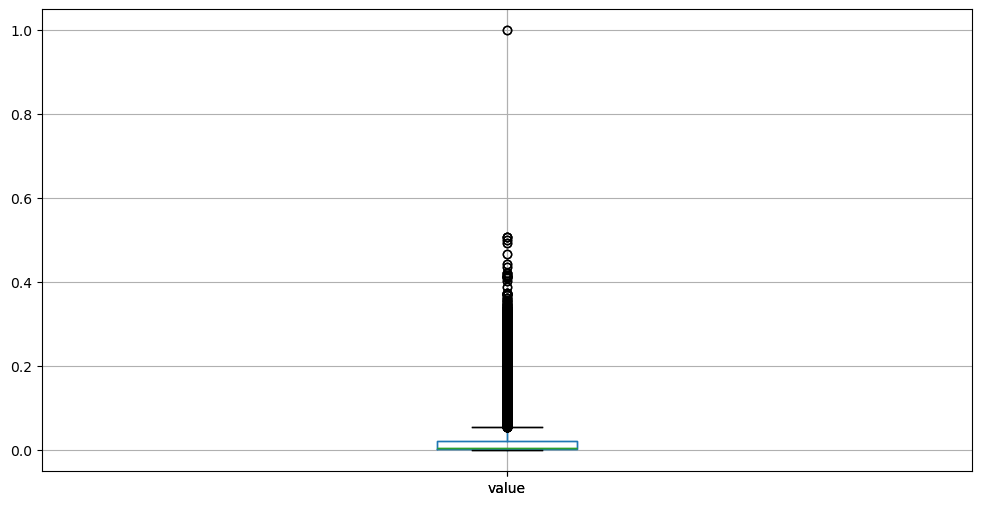

In [32]:
df_hic.boxplot(column='value', figsize=(12, 6))
plt.show()